In [483]:
import math
import numpy as np
import pandas as pd
import pandapower as pp
import pandapower.networks as pn
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import spearmanr, pearsonr

# helper functions for plotting graphs and waveforms

# prints graph
def print_graph(G: nx.Graph):
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1000, font_size=16)
    plt.show()


# plots the graph waveform
def plot_node_waveforms(S, nodes):
    t = np.arange(S.shape[0])
    n = len(nodes)

    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = np.array(axes).reshape(-1)

    for i, node in enumerate(nodes):
        axes[i].plot(t, S[:, i])
        axes[i].set_title(f'Node {node}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Flow')
        axes[i].grid(True)

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


# plots the edge waveform
def plot_edge_waveforms(F, edges):
    t = np.arange(F.shape[0])
    n = len(edges)

    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = np.array(axes).reshape(-1)

    for i, (u, v) in enumerate(edges):
        axes[i].plot(t, F[:, i])
        axes[i].set_title(f'Edge ({u},{v})')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Flow')
        axes[i].grid(True)

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()



First we build small weighted graph for calculating physics based centrality formulas. We compute effective resistance, current flow betweenness, and a simple DC power flow to see how they relate to each other. The goal is just to test and better understand these formulas on a small example.

Graph structure:



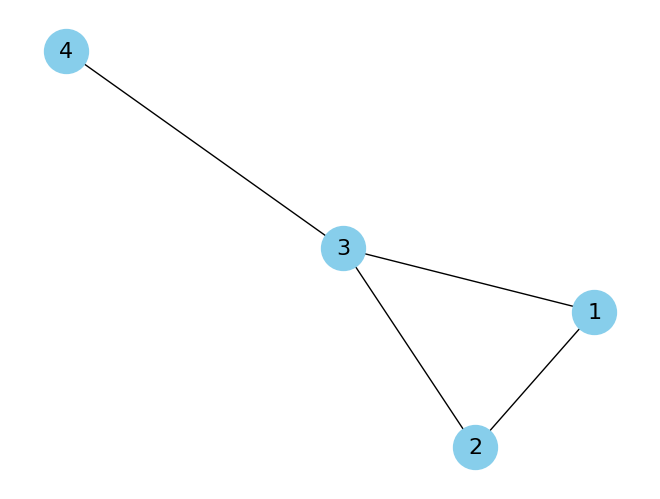


Effective Resistance:
(1, 2): 0.7778
(1, 3): 0.5556
(2, 3): 0.6667
(3, 4): 1.0000

Current Flow Betweenness:
(1, 2): 0.3889
(1, 3): 0.3333
(2, 3): 0.4074
(3, 4): 0.5000

DC Power Flow:
(1, 2): 0.4444
(1, 3): 0.5556
(2, 3): 0.4444
(3, 4): 1.0000


In [484]:

# create random graph with edge features
G = nx.Graph()
edges = [
    (1,2, {'x': 0.1, 'capacity': 5}),
    (1,3, {'x': 0.2, 'capacity': 5}),
    (2,3, {'x': 0.15, 'capacity': 5}),
    (3,4, {'x': 0.3, 'capacity': 5})
]
G.add_edges_from(edges)

# define some node features
nodes = list(G.nodes())
n = len(nodes)
node_index = {node: i for i, node in enumerate(nodes)}

# calculate edge weight B = 1 / X
for u,v,data in G.edges(data=True):
    data['weight'] = 1 / data['x']

# print our graph
print('Graph structure:\n')
print_graph(G)

# calculate Laplacian and its pseudo inverse
L = nx.laplacian_matrix(G, nodelist=nodes, weight='weight').toarray()
L_plus = np.linalg.pinv(L)


# function that computes effective resistance centrality
def compute_effective_resistance(G, L_plus, node_index):
    n = len(node_index)
    eff_cent = {}
    
    # helper that computes R_eff for given edge
    def R_eff(i, j):
        ei = np.zeros(n)
        ej = np.zeros(n)
        ei[node_index[i]] = 1
        ej[node_index[j]] = 1
        diff = ei - ej

        # R_eff = (e_i - e_j)^T * L^+ * (e_i - e_j)
        return diff @ L_plus @ diff

    # iterate over each edge and compute its effective resistace
    for (u,v) in G.edges():
        w = G[u][v]['weight']
        # compute C_e = w_e * R_eff
        eff_cent[(u,v)] = w * R_eff(u, v)
    
    return eff_cent


# function that computes current flow betweenness centrality
def compute_current_flow_betweenness(G, L_plus, node_index):
    nodes = list(G.nodes())
    n = len(nodes)
    curr_flow = {e:0.0 for e in G.edges()}

    # iterate over all unordered node pairs (s, t)
    for s in nodes:
        for t in nodes:
            if s >= t:
                continue
            b = np.zeros(n)
            b[node_index[s]] = 1
            b[node_index[t]] = -1

            # solve for node voltages: x = L^+ b
            x = L_plus @ b

            # compute induced current on each edge
            for (u,v) in G.edges():
                i, j = node_index[u], node_index[v]
                w = G[u][v]['weight']
                flow = w * (x[i] - x[j])
                curr_flow[(u,v)] += abs(flow)

    # normalize by number of node pairs
    num_pairs = n*(n-1)/2
    for e in curr_flow:
        curr_flow[e] /= num_pairs

    return curr_flow


# function that computes simulated DC power flow for flow centrality (estimation)
def compute_dc_power_flow(G, L_plus, node_index):
    nodes = list(G.nodes())
    P = np.zeros(len(nodes))
    P[node_index[1]] = 1.0
    P[node_index[4]] = -1.0

    theta = L_plus @ P

    dc_flow = {}
    for (u,v) in G.edges():
        i, j = node_index[u], node_index[v]
        w = G[u][v]['weight']
        dc_flow[(u,v)] = w * (theta[i] - theta[j])

    return dc_flow


# run calculations for given metrics
eff_cent = compute_effective_resistance(G, L_plus, node_index)
curr_flow = compute_current_flow_betweenness(G, L_plus, node_index)
dc_flow = compute_dc_power_flow(G, L_plus, node_index)

print('\nEffective Resistance:')
for e, val in eff_cent.items():
    print(f'{e}: {val:.4f}')

print('\nCurrent Flow Betweenness:')
for e, val in curr_flow.items():
    print(f'{e}: {val:.4f}')

print('\nDC Power Flow:')
for e, val in dc_flow.items():
    print(f'{e}: {val:.4f}')


Here we Implement the network auralization algorithm for nodes, similar to original one but uses numpy for ease of use. Testing it on several graphs that have a node bottleneck, plotting the waveform for each node to see its effective influence on the network.

[[ 9.11412766e-07  9.11412766e-07  9.11412766e-07 ...  9.11412766e-07
   9.11412766e-07  4.99990465e-01]
 [-4.99990886e-02 -4.99990886e-02 -4.99990886e-02 ... -4.99990886e-02
  -4.99990886e-02 -1.00009535e-01]
 [-3.64990886e-02 -3.64990886e-02 -3.64990886e-02 ... -3.64990886e-02
  -3.64990886e-02 -4.88009535e-01]
 ...
 [ 4.69791570e-06  4.69791570e-06  4.69791570e-06 ...  4.69791574e-06
   4.69791574e-06 -4.35236891e-06]
 [-1.77830651e-06 -1.77830651e-06 -1.77830651e-06 ... -1.77830649e-06
  -1.77830649e-06 -1.60739008e-05]
 [-4.64689092e-06 -4.64689092e-06 -4.64689092e-06 ... -4.64689091e-06
  -4.64689091e-06 -1.54105539e-05]]


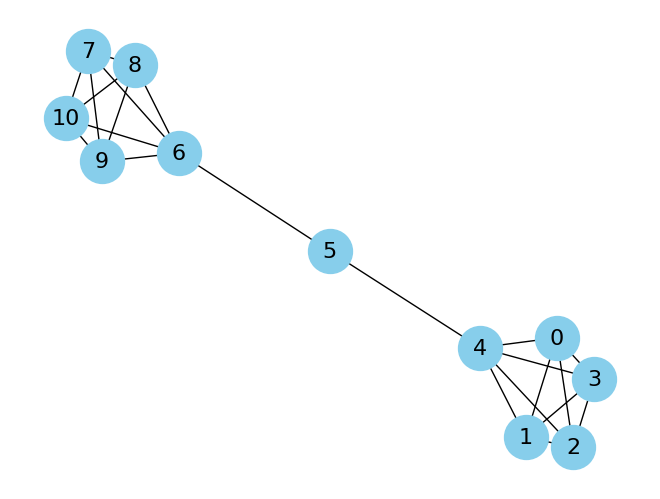

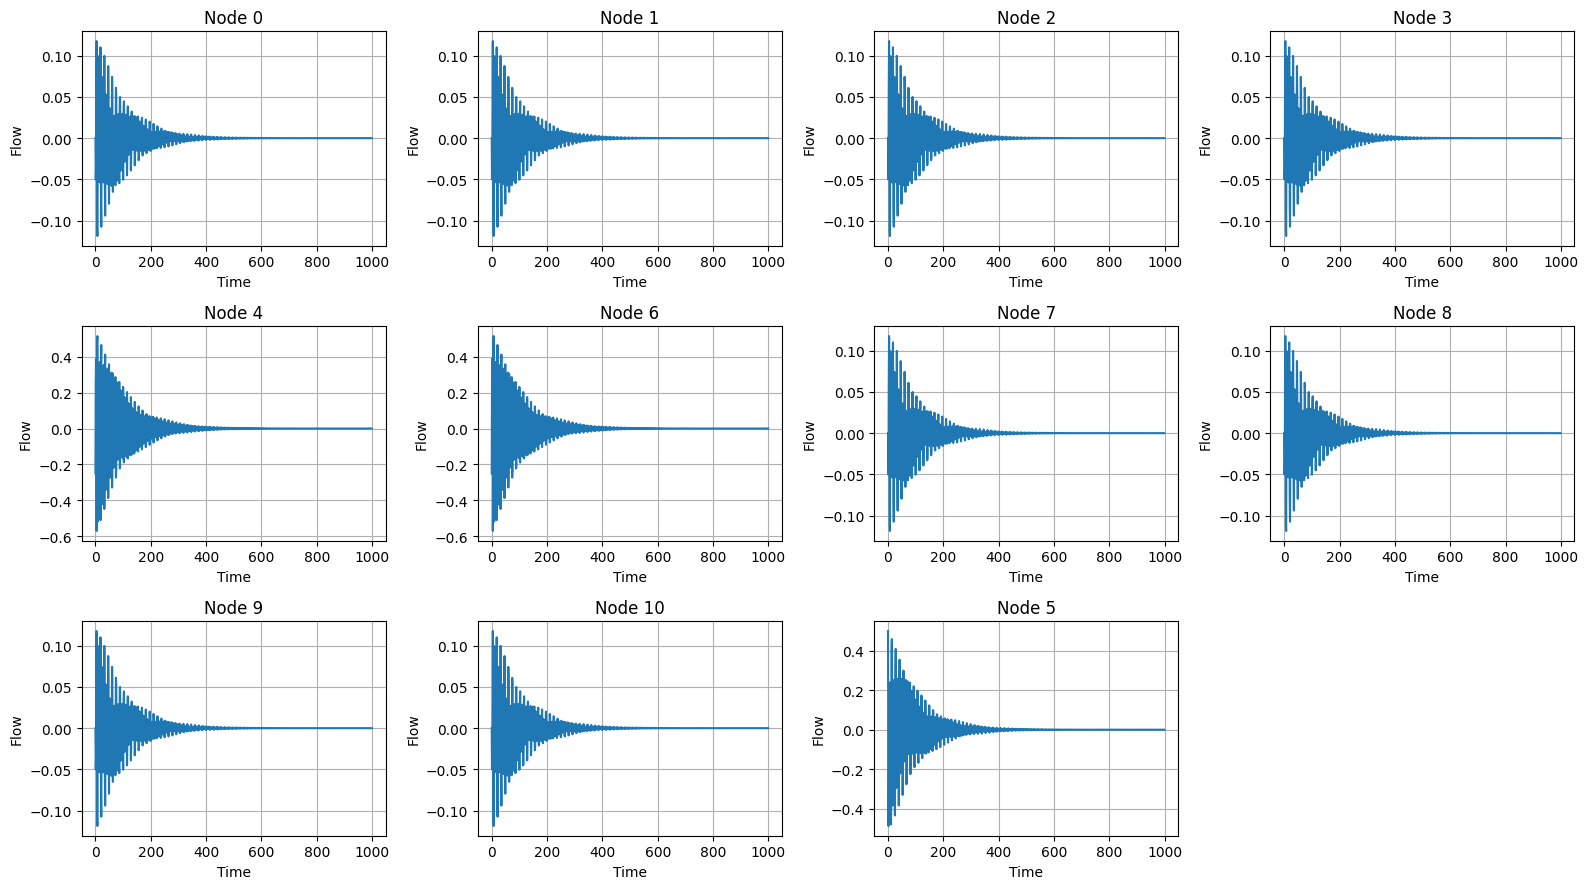

In [485]:

def network_auralization(G, nodes, sig=None, m=0.9, l=100):
    n = len(nodes)

    # adjacency matrix for given graph G
    A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')

    # initialize transition matrix and with normalize columns for getting
    # transition probabilites for each node (power it may apply to its neighbors)
    col_sum = A.sum(axis=0) + 1e-32 # add small value to avoid division by zero
    P = (A / col_sum).T

    # initialize S matrix with initial condition
    S = np.zeros((l, n))

    # initialize delta S matrix to zeros for initail flow between nodes 
    DELTA_S = np.zeros((n, n))

    # if no signal provided, use default condition (1 for all nodes at time 0)
    if sig is None:
        sig = np.zeros(l)
        sig[0] = 1

    # simulation of wave propagation over l time steps
    for t in range(1, l):
        # add signal injection to St-1 before propagation
        S[t-1] += sig[(t-1) % len(sig)]

        # create diagonal matrix from St-1
        diag_S = np.diag(S[t-1])

        # update delta_S based on how much power each node applies to its neighbors
        DELTA_S = diag_S @ P + m * DELTA_S # include previous flow momentum

        # calculate inflow and outflow for each node
        inflow = DELTA_S.sum(axis=0)
        outflow = DELTA_S.sum(axis=1)

        # update S based on inflow and outflow
        S[t] = S[t-1] + inflow - outflow

    # remove DC component
    S = S - S.mean(axis=0)

    return S



# test the network auralization function on small graphs
G_star = nx.star_graph(5)

G_path = nx.path_graph(6)

G_bottleneck = nx.Graph()
G_bottleneck.add_edges_from([
    (1,2),(2,3),(3,4),
    (4,5),(5,6),
    (3,7),(7,8)
])

G_bottleneck2 = nx.Graph()
G_bottleneck2.add_edges_from([
    (1,2), (1,3), (2,3), (3,4)
])

G_barbell = nx.barbell_graph(5, 1)

G_grid = nx.grid_2d_graph(5,5)
G_grid = nx.convert_node_labels_to_integers(G_grid)

# test graph
G = G_barbell
nodes = list(G.nodes())

S = network_auralization(G, nodes, m=0.98, l=1000)
print(S)
print_graph(G)
plot_node_waveforms(S, nodes)



Here, I implemented the network auralization algorithm for edges, similar to the original approach, but using a new F matrix that stores a time series for each edge. Each edge’s series is computed as F[(u,v)] = S[u] + S[v].<br> Tested it on pervious graphs from earlier and plotted waveform for edges for visualization.

[[ 5.01636768e-06 -4.99993769e-01 -4.99993769e-01 -5.01636761e-06]
 [-3.33328317e-01  3.33339564e-01  3.33339564e-01  3.33328317e-01]
 [-1.59994984e-01  5.66672898e-01  5.66672898e-01  1.59994984e-01]
 ...
 [ 2.51041267e-06 -7.45181335e-06 -7.45181335e-06 -2.51041262e-06]
 [-9.00663982e-06  2.73796024e-05  2.73796024e-05  9.00663985e-06]
 [ 5.49165001e-06  2.50979017e-05  2.50979017e-05 -5.49164999e-06]]


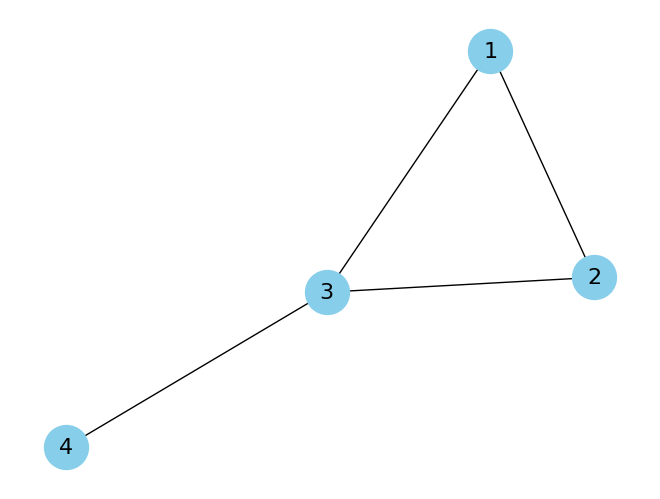

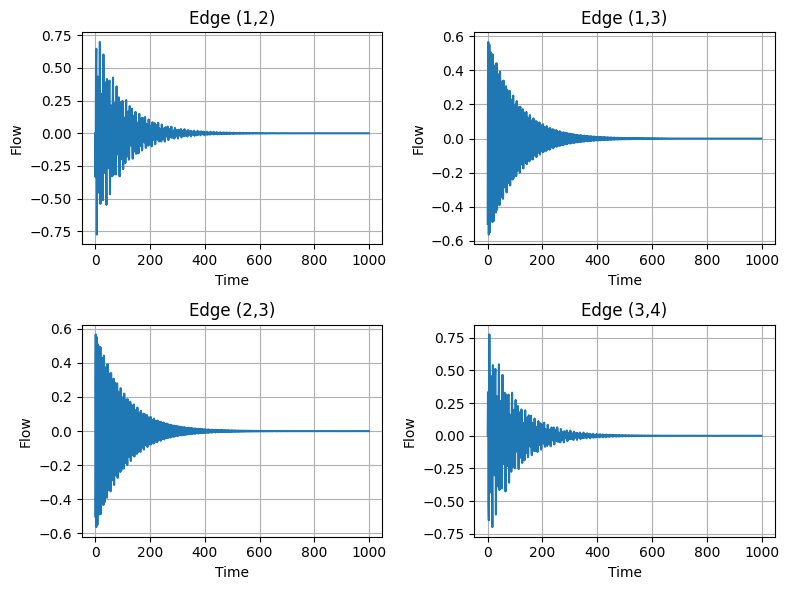

In [486]:

def network_auralization_edges(G, nodes, edges, sig=None, m=0.9, l=100):
    n = len(nodes)
    m_edges = len(edges)
    node_index = {node: i for i, node in enumerate(nodes)}

    # adjacency matrix for given graph G
    A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')

    # initialize transition matrix and with normalize columns for getting
    # transition probabilites for each node (power it may apply to its neighbors)
    col_sum = A.sum(axis=0) + 1e-32 # add small value to avoid division by zero
    P = (A / col_sum).T

    # initialize S matrix with initial condition
    S = np.zeros((l, n))

    # initialize delta_S matrix to zeros for initail flow between nodes 
    DELTA_S = np.zeros((n, n))

    #? this is for edge-based flow, we need to track flow on edges, we create row and colum indices for edges
    #? each edge (u, v) gets its own index / number, so we can track flows for it
    row_idx = np.array([node_index[u] for u, v in edges])
    col_idx = np.array([node_index[v] for u, v in edges])

    #? Ft matrix represents flow on edges over time (like St)
    F = np.zeros((l, m_edges))

    # if no signal provided, use default condition (1 for all nodes at time 0)
    if sig is None:
        sig = np.zeros(l)
        sig[0] = 1

    # simulation of wave propagation over l time steps
    for t in range(1, l):
        # add signal injection to St-1 before propagation
        S[t-1] += sig[(t-1) % len(sig)]

        # create diagonal matrix from St-1
        diag_S = np.diag(S[t-1])

        # update delta_S based on how much power each node applies to its neighbors
        DELTA_S = diag_S @ P + m * DELTA_S # include previous flow momentum

        # calculate inflow and outflow for each node
        inflow = DELTA_S.sum(axis=0)
        outflow = DELTA_S.sum(axis=1)

        # update S based on inflow and outflow
        S[t] = S[t-1] + inflow - outflow

    #? calculate flow on edges from S, represent flow on edge (u, v) as S[u] + S[v] (flow on both nodes)
    F = S[:, row_idx] + S[:, col_idx]

    #? remove DC component for edge flows
    F = F - F.mean(axis=0)

    return F



# test the network auralization function on small graphs
G_star = nx.star_graph(5)

G_path = nx.path_graph(6)

G_bottleneck = nx.Graph()
G_bottleneck.add_edges_from([
    (1,2),(2,3),(3,4),
    (4,5),(5,6),
    (3,7),(7,8)
])

G_bottleneck2 = nx.Graph()
G_bottleneck2.add_edges_from([
    (1,2), (1,3), (2,3), (3,4)
])

G_barbell = nx.barbell_graph(5, 1)

G_grid = nx.grid_2d_graph(5,5)
G_grid = nx.convert_node_labels_to_integers(G_grid)

# test graph
G = G_bottleneck2
nodes, edges = list(G.nodes()), list(G.edges())

F = network_auralization_edges(G, nodes, edges, m=0.98, l=1000)
print(F)
print_graph(G)
plot_edge_waveforms(F, edges)



In this section we start working on power grid networks, using PandaPower to compute power flow on various IEEE networks. In this section we have simple helper functions for converting PandaPower network to networkX graphs and plotting it for visualization. Note that we compute the suseptance for each edge and have it as a weight for later calculations.

In [487]:
# function for building network graph including various power network features for buses and branches
def build_network_graph(network: pp.pandapowerNet, is_weighted=True):
    G = nx.MultiGraph()
    NUM_LINES = len(network.line)

    # represents nodes and edges lists, we maintain them for later easy access to features
    nodes, edges = [], []

    # add nodes to our network graph
    for bus in network.bus.index:
        vn_kv = network.bus.at[bus, 'vn_kv'] # nominal voltage
        p_load = network.load[network.load.bus == bus].p_mw.sum() if not network.load.empty else 0.0 # active load
        q_load = network.load[network.load.bus == bus].q_mvar.sum() if not network.load.empty else 0.0 # reactive load
        p_sgen = network.sgen[network.sgen.bus == bus].p_mw.sum() if not network.sgen.empty else 0.0 # active static generation
        q_sgen = network.sgen[network.sgen.bus == bus].q_mvar.sum() if not network.sgen.empty else 0.0 # reactive static generation
        p_gen = network.gen[network.gen.bus == bus].p_mw.sum() if not network.gen.empty else 0.0 # active conventional generation

        G.add_node(bus, vn_kv=vn_kv, p_load=p_load, q_load=q_load, p_sgen=p_sgen, q_sgen=q_sgen, p_gen=p_gen)
        nodes.append(bus)

    # add edges for lines to our network graph
    for idx, (pp_idx, line) in enumerate(network.line.iterrows()):
        r = line.r_ohm_per_km * line.length_km # resistance of line
        x = line.x_ohm_per_km * line.length_km # reactance of line
        z = np.sqrt(r**2 + x**2) # impedance magnitude |Z| = sqrt(R^2 + X^2)
        y_mag = 1 / max(z, 1e-6) # admittance magnitude |Y| = 1 / |Z|
        rx_ratio = r / max(x, 1e-6) # ratio between resistance & reactance

        G.add_edge(line.from_bus, line.to_bus, key=f'line_{idx}', index=idx, pp_index=pp_idx, type='line', r=r, x=x, z=z, y_mag=y_mag, rx_ratio=rx_ratio, weight=y_mag if is_weighted else 1.0)
        edges.append((line.from_bus, line.to_bus, f'line_{idx}'))

    # add edges for transformers to our network graph
    for idx, (pp_idx, trafo) in enumerate(network.trafo.iterrows()):
        r = trafo.vkr_percent / 100 * (trafo.vn_hv_kv ** 2) / trafo.sn_mva # resistance of line
        x = np.sqrt(max((trafo.vk_percent / 100)**2 - (trafo.vkr_percent / 100)**2, 0)) * (trafo.vn_hv_kv ** 2) / trafo.sn_mva # reactance of line
        z = np.sqrt(r**2 + x**2) # impedance magnitude
        y_mag = 1 / max(z, 1e-6) # admittance magnitude
        rx_ratio = r / (x + 1e-6) # ratio between resistance & reactance

        G.add_edge(trafo.hv_bus, trafo.lv_bus, key=f'trafo_{idx}', index=NUM_LINES + idx, pp_index=pp_idx, type='trafo', r=r, x=x, z=z, y_mag=y_mag, rx_ratio=rx_ratio, weight=y_mag if is_weighted else 1.0)
        edges.append((trafo.hv_bus, trafo.lv_bus, f'trafo_{idx}'))

    # we return new graph with nodes and edges lists
    return G, nodes, edges


# function for printing network graph for visualization
def print_network_graph(G: nx.MultiGraph, title=''):
    # define our figure size based on num of nodes
    num_nodes = len(G.nodes)
    fig_width = max(10, num_nodes // 5)
    fig_height = max(8, num_nodes // 5)
    plt.figure(figsize=(fig_width, fig_height))

    # if small graph print shell layout, else spring for larger graphs
    if num_nodes <= 20:
        pos = nx.shell_layout(G)
    else:
        pos = nx.spring_layout(G, seed=42, k=0.5 / (num_nodes**0.5), iterations=200)

    # draw our nodes and labels
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=9)

    # get edges type to draw them seperately (lines vs transformers)
    line_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('type') == 'line']
    trafo_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('type') != 'line']

    # draw our edges, transformers are dashed
    nx.draw_networkx_edges(G, pos, edgelist=line_edges, edge_color='black', width=2)
    nx.draw_networkx_edges(G, pos, edgelist=trafo_edges, edge_color='grey', style='dashed', width=2)

    # draw edge label indices for referace later on
    edge_labels = {(u, v): d.get('index', '') for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # draw small legend for buses, lines and transformers
    bus_legend = mlines.Line2D([], [], color='lightblue', marker='o', linestyle='None', markersize=8, label='Bus')
    line_legend = mlines.Line2D([], [], color='black', linewidth=2, label='Line')
    trafo_legend = mlines.Line2D([], [], color='grey', linestyle='dashed', linewidth=2, label='Transformer')
    plt.legend(handles=[bus_legend, line_legend, trafo_legend], loc='upper right')

    plt.title(f'{title} Network Graph: Buses, Lines & Transformers (dashed)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In this section, I implemented the main function to simulate network power flow. First, we compute the baseline flow with all links and transformers connected. Then, we simulate an outage on each branch and measure how the flows change on the rest of the network. Both AC and DC flows can be measured, and the results are stored in a delta_P matrix, where each row shows the power changes on all branches when a specific link is disconnected.

In [ ]:

# fucntion for computing edge betweeness centrality for our network graph
def compute_edge_betweeness(G: nx.Graph, is_weighted=True):
    edge_betweenness = nx.edge_betweenness_centrality(G, weight='weight' if is_weighted else None)
    betweenness_values = np.zeros(len(G.edges()))

    # iterate over edges and assign betweenness values based on our edge index from graph
    for u, v, k, d in G.edges(keys=True, data=True):
        idx = d['index']
        betweenness_values[idx] = edge_betweenness[(u, v, k)]
    
    return betweenness_values


# simulate power flow on network, AC or DC
def run_power_flow(network: pp.pandapowerNet, use_dc=False):
    pp.runpp(network) if not use_dc else pp.rundcpp(network)


# main function for simulating network outage on edges and compute delta_P matrix
def network_outage_impact(network: pp.pandapowerNet, G: nx.MultiGraph, edges, use_dc=False, use_abs=True):
    # define number of branches in given network
    NUM_BRANCHES = len(edges)

    # define our delta_P matrix that represents each line impact
    # on the other lines (power outage)
    DELTA_P = np.zeros((NUM_BRANCHES, NUM_BRANCHES))

    # compute network power baseline with all lines connected
    run_power_flow(network, use_dc)
    baseline_lines = network.res_line['p_from_mw'].values
    baseline_trafos = network.res_trafo['p_hv_mw'].values
    baseline = np.concatenate([baseline_lines, baseline_trafos])

    # iterate over each line/tarnfo and simulate its outage, compute new power flow on network
    for (u, v, k) in edges:
        # get edge indices and type for simulating outage
        edge_idx = G[u][v][k]['index']
        pp_idx = G[u][v][k]['pp_index']
        edge_type = G[u][v][k]['type']

        # remove current line/tranfo from our network
        if edge_type == 'line':
            network.line.at[pp_idx, 'in_service'] = False
        else:
            network.trafo.at[pp_idx, 'in_service'] = False

        try:
            # run full power flow on our network without currrnt line/tranfo and compute new flow
            run_power_flow(network, use_dc)
            flow_lines = network.res_line['p_from_mw'].values
            flow_trafos = network.res_trafo['p_hv_mw'].values
            total_flow = np.concatenate([flow_lines, flow_trafos])

            # compute the delta between new flow and baseline, use absolute if given
            DELTA_P[edge_idx] = total_flow - baseline if not use_abs else np.abs(total_flow - baseline)

        #! if exception occured it means power flow didnt converge, means network is unstable or got disconnected, importent case to handle
        except pp.LoadflowNotConverged:
            # assign large value to delta to indicate significant impact for this line/tranfo
            max_delta = np.nanmax(DELTA_P)
            DELTA_P[edge_idx] = max_delta + 0.1 * max_delta

        # add current line/tranfo back to out network for later iterations
        if edge_type == 'line':
            network.line.at[pp_idx, 'in_service'] = True
        else:
            network.trafo.at[pp_idx, 'in_service'] = True
    
    return DELTA_P, baseline


# helper fucntion for computing flow centrality on given network using our simulation
def compute_flow_centrality(network: pp.pandapowerNet, G: nx.MultiGraph, edges, use_dc=False, normalize=False):
    DELTA_P, _ = network_outage_impact(network, G, edges, use_dc=use_dc)
    impact = np.linalg.norm(DELTA_P, axis=1)

    # return normalized impact values using min-max normalization
    if normalize:
        impact = (impact - impact.min()) / (impact.max() - impact.min() + 1e-12)

    return impact



Helper functions for plotting various metrics for later visualization.

In [489]:
# function for plotting heatmap of outage impact matrix
def plot_outage_heatmap(delta_p, title='Branch Outage Impact Matrix', cmap='coolwarm', show_values=True, max_fig_size=40, max_ticks=50):
    # define figure size
    n = delta_p.shape[0]
    fig_width = min(max(8, n*0.4), max_fig_size)
    fig_height = min(max(6, n*0.4), max_fig_size)
    plt.figure(figsize=(fig_width, fig_height))

    # plot heatmap with colorbar
    im = plt.imshow(delta_p, cmap=cmap, origin='lower', aspect='auto', interpolation='none')
    plt.colorbar(im, label='ΔP (MW)')

    # set adaptive ticks based on number of branches
    ticks = np.arange(0, n, max(1, n // max_ticks))
    plt.xticks(ticks)
    plt.yticks(ticks)
    plt.xlabel('Affected branch j')
    plt.ylabel('Outaged branch i')
    plt.title(title)

    # show cell values only for small networks
    if show_values and n <= 100:
        for i in range(n):
            for j in range(n):
                plt.text(j, i, f'{delta_p[i, j]:.1f}', ha='center', va='center', fontsize=6)

    plt.tight_layout()
    plt.show()


# function for plotting top-k most impactful branches based on outage impact metric
def plot_top_k(metric, order_by=None, xlabel='X', ylabel='Y', title='Top K', top_k=20, color='steelblue'):
    n = len(metric)
    k = min(top_k, n)

    if order_by is None:
        order_by = metric

    sorted_idx = np.argsort(metric)[::-1]
    indices = sorted_idx[:k]
    values = metric[indices]

    plt.figure(figsize=(12, 5))
    plt.bar(range(k), values, color=color, width=0.7)
    plt.xticks(range(k), indices, rotation=45)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if top_k < n:
        plt.title(f'{title} (Top {k} of {n})')
    else:
        plt.title(f'{title} (All {n}, sorted)')

    plt.tight_layout()
    plt.show()


# function for plotting scatter plot comparing two metrics for each branch
def plot_scatter(x, y, xlabel='X', ylabel='Y', title='Scatter Plot', alpha=None, color='steelblue'):
    plt.figure()
    plt.scatter(x, y, alpha=alpha, color=color)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()



Test IEEE-14 network, 14 buses and 20 branches (links + transformers).

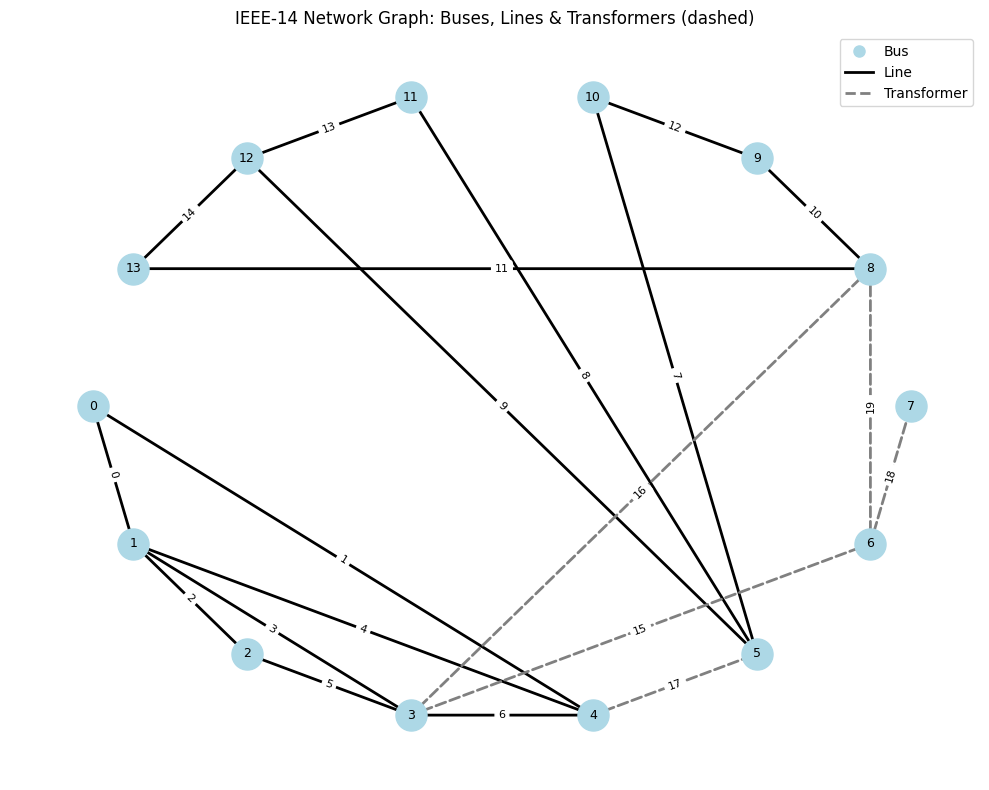

Network baseline:
 [ 1.56882891e+02  7.55103818e+01  7.32375792e+01  5.61314959e+01
  4.15162150e+01 -2.32856901e+01 -6.11582304e+01  7.35327698e+00
  7.78606702e+00  1.77479769e+01  5.22755247e+00  9.42638103e+00
 -3.78532238e+00  1.61425777e+00  5.64385098e+00  2.80741759e+01
  1.60797576e+01  4.40873209e+01 -1.46549439e-14  2.80741759e+01]


In [490]:
# represents results list for each IEEE network we test, we store results here for later analysis
network_results = []

# test outage simulation on IEEE14 network
network = pn.case14()
network_name = 'IEEE-14'
G, nodes, edges = build_network_graph(network)
print_network_graph(G, title=network_name)

# simulate network outage on edges and get delta_P matrix
DELTA_P, baseline = network_outage_impact(network, G, edges, use_abs=False)

# noirmalize delta_P by baseline to get relative impact of each line outage
DELTA_P_REL = DELTA_P / (np.abs(baseline) + 1e-9)

# print network baseline
print(f'Network baseline:\n {baseline}')

Show heatmap plot of link outage impacts on IEEE-14 network.

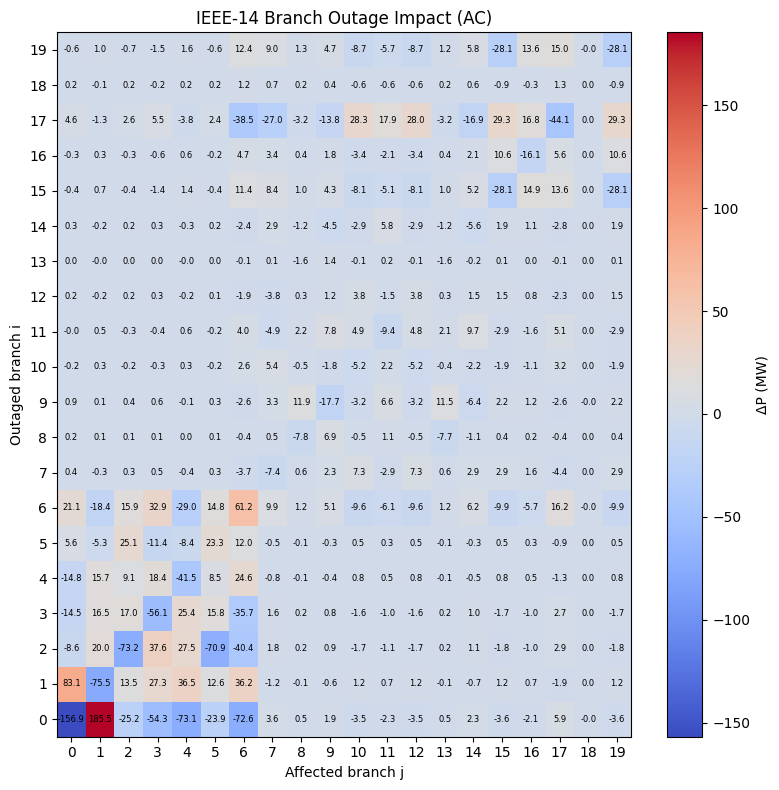

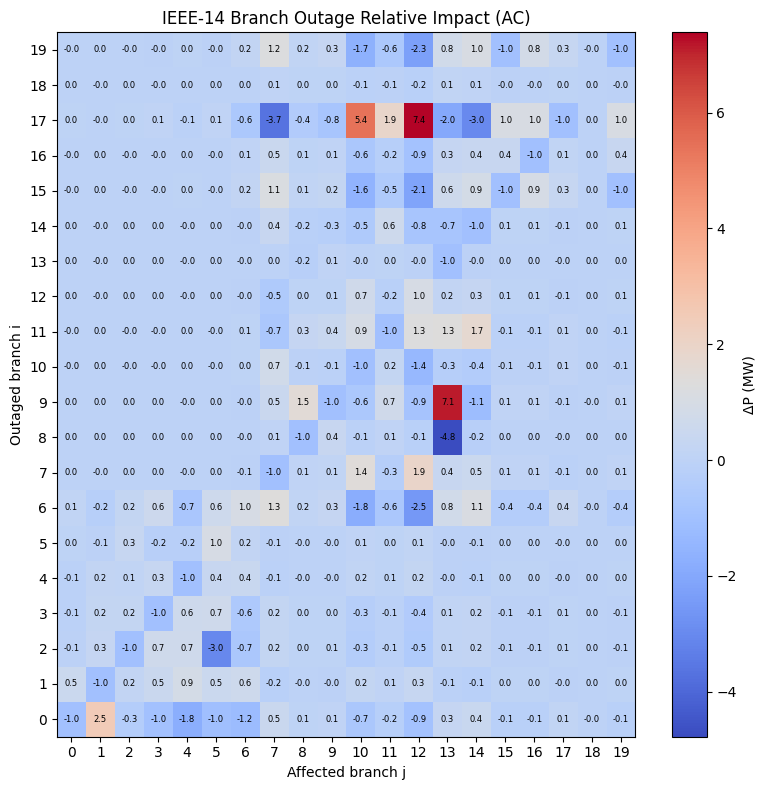

In [491]:
# plot two heatmaps, one for absolute impact and one for relative impact, later choose one that better reflects the network
plot_outage_heatmap(DELTA_P, title=f'{network_name} Branch Outage Impact (AC)')

plot_outage_heatmap(DELTA_P_REL, title=f'{network_name} Branch Outage Relative Impact (AC)')

Plot top k important links based on their impact on the IEEE-14 network.

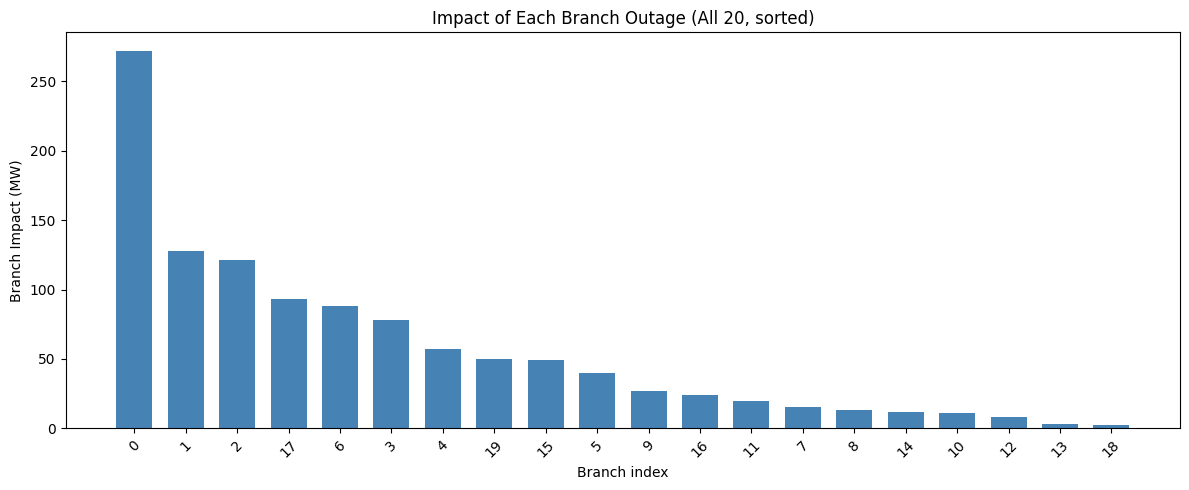

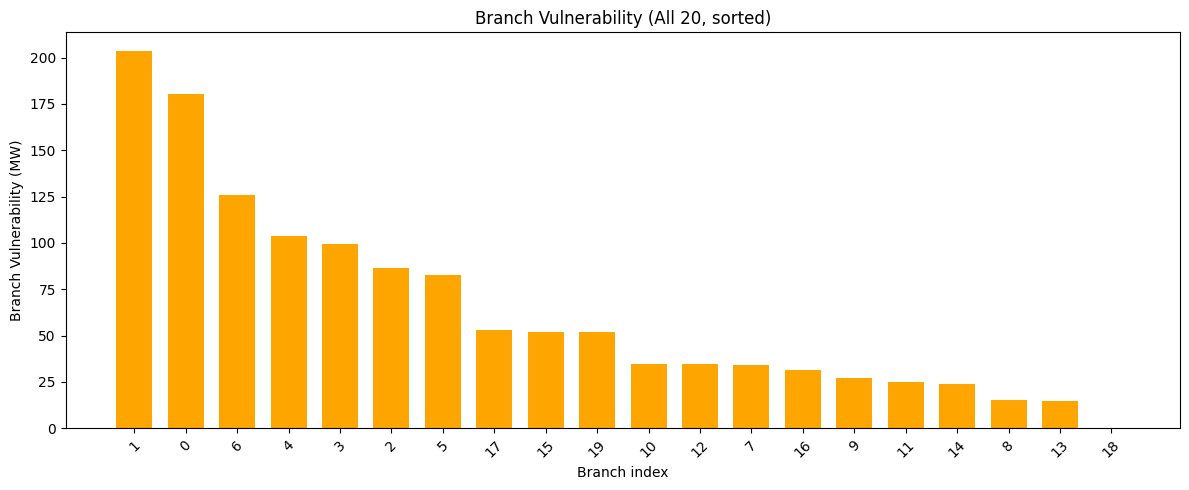

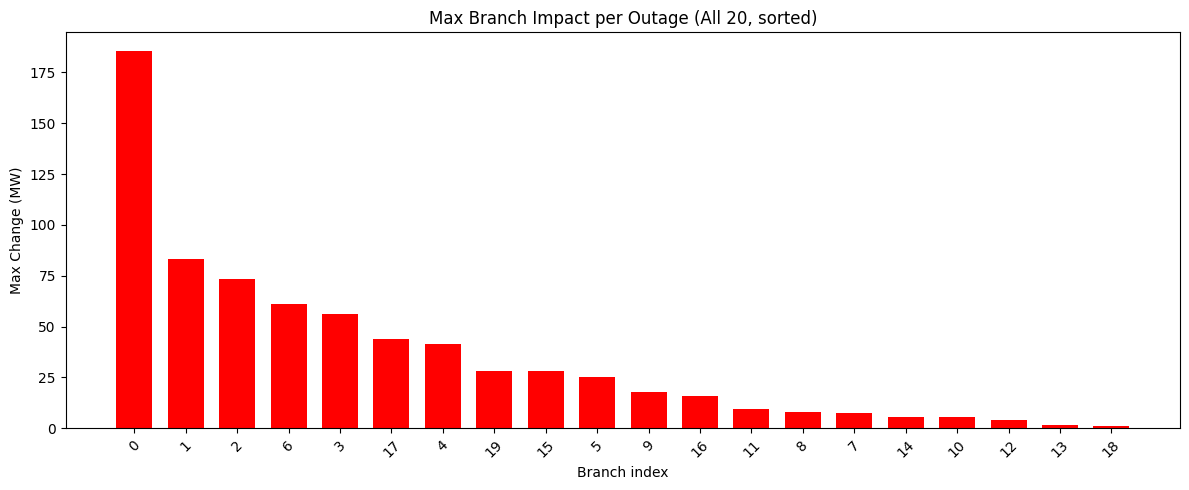

In [492]:

# we compute L2 norm for each row to get overall impact of each branch / link removal from the network
# this gives us single metric for each branch that captures its overall impact
link_impact = np.linalg.norm(DELTA_P, ord=2, axis=1)

# we compute L2 norm for each column to get overall vulnerability of each branch / link to outages in the network
link_vulnerability = np.linalg.norm(DELTA_P, ord=2, axis=0)

# also compute max impact for each branch to compute worst case impact
link_max_impact = np.max(np.abs(DELTA_P), axis=1)

# finally we compute flow centrality by normalizing link impact to get relative importance for each branch in the network
flow_centrality = link_impact / (link_impact.max() + 1e-12)


# plot top k branches by impact, vulnurability and max impact
plot_top_k(link_impact, xlabel='Branch index', ylabel='Branch Impact (MW)', title='Impact of Each Branch Outage', color='steelblue')

plot_top_k(link_vulnerability, xlabel='Branch index', ylabel='Branch Vulnerability (MW)', title='Branch Vulnerability', color='orange')

plot_top_k(link_max_impact, xlabel='Branch index', ylabel='Max Change (MW)', title='Max Branch Impact per Outage', color='red')


Compare topological edge betweenness centrality to your power flow centrality measurement (Physical vs topology).

Edge Betweenness Centrality:
 [0.         0.14285714 0.07692308 0.43956044 0.50549451 0.06593407
 0.         0.26373626 0.12087912 0.         0.         0.24175824
 0.14285714 0.02197802 0.14285714 0.26373626 0.34065934 0.41758242
 0.14285714 0.        ]


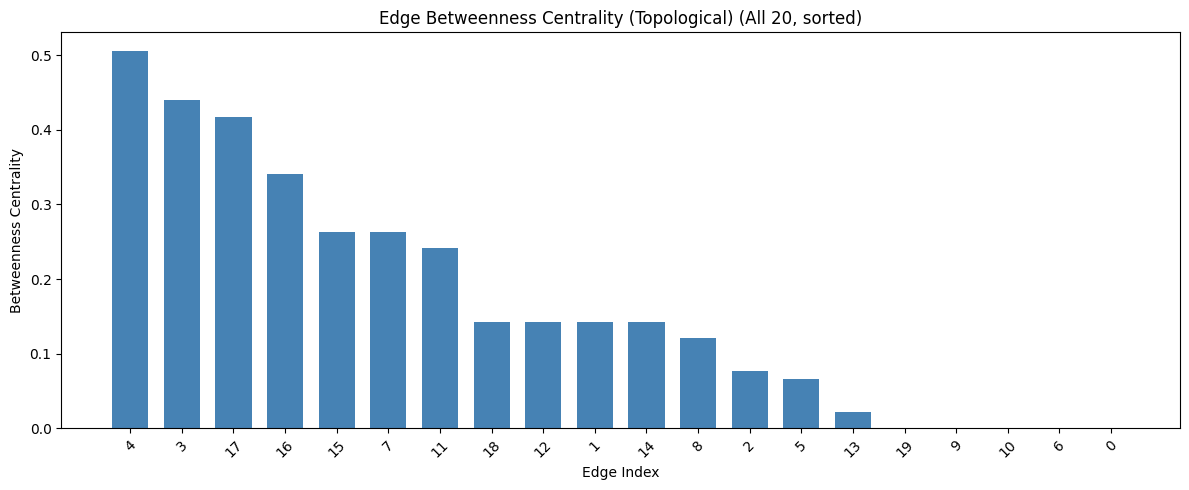

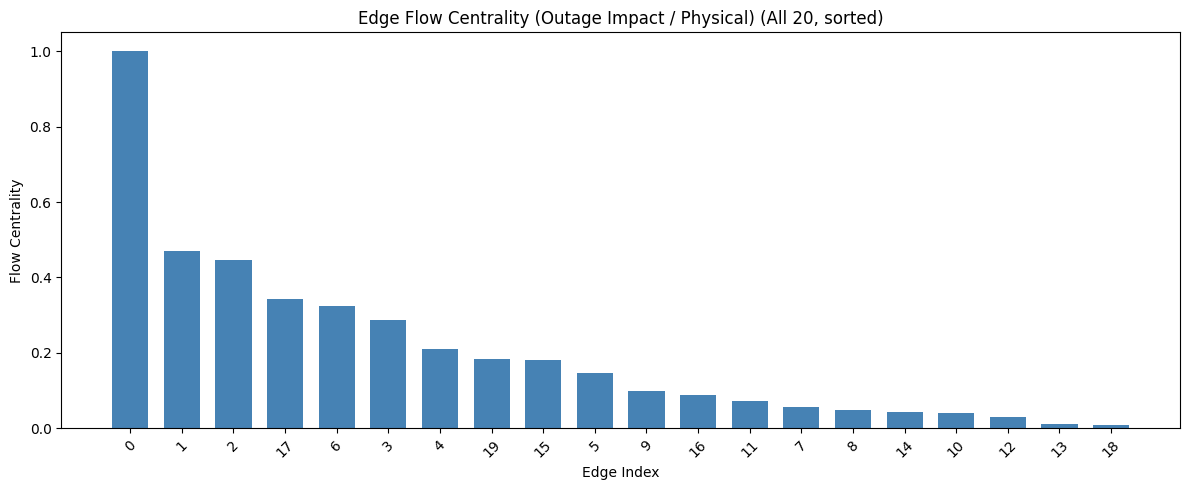

In [493]:
# compute edge betweeness centrality for our network and comapre to flow centrality of outages
edge_betweenness = compute_edge_betweeness(G)
print(f'Edge Betweenness Centrality:\n {edge_betweenness}')


# plot edge betweeness and flow for comparison between topological and physical centrtality measures
plot_top_k(edge_betweenness, title='Edge Betweenness Centrality (Topological)', xlabel='Edge Index', ylabel='Betweenness Centrality', color='steelblue')

plot_top_k(flow_centrality, title='Edge Flow Centrality (Outage Impact / Physical)', xlabel='Edge Index', ylabel='Flow Centrality', color='steelblue')


We compare the relationship between edge betweenness and flow centrality. On the IEEE-14 network, the correlation between edge betweenness and physical flow is weak, indicating that the flow based measure is much more relevant for this network.

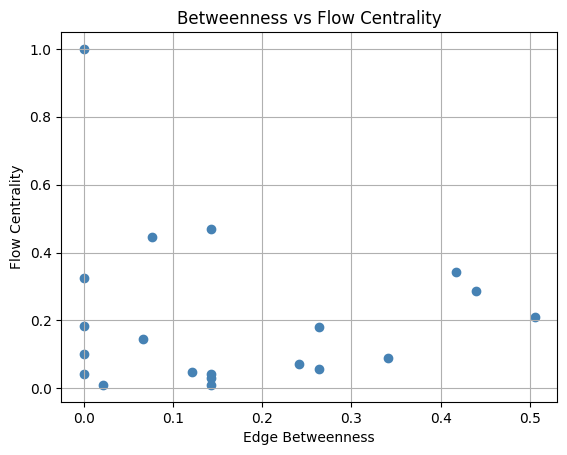

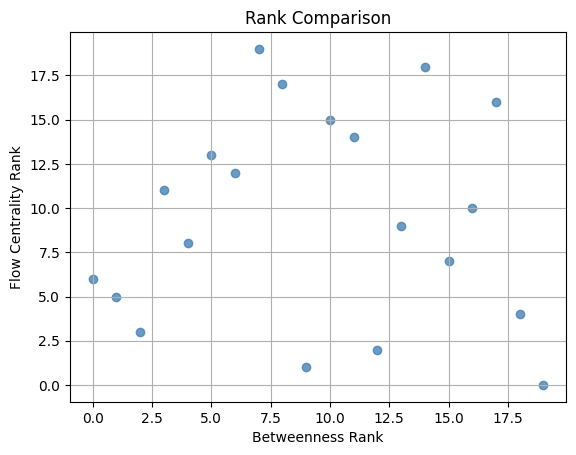

In [494]:
# print scatter plot comparing edge betweenness and flow centrality
plot_scatter(edge_betweenness, flow_centrality, xlabel='Edge Betweenness', ylabel='Flow Centrality', title='Betweenness vs Flow Centrality')

# print scatter plot comparing edge betweenness and flow centrality ranks
rank_flow = np.argsort(np.argsort(flow_centrality)[::-1])
rank_betw = np.argsort(np.argsort(edge_betweenness)[::-1])
plot_scatter(rank_betw, rank_flow, xlabel='Betweenness Rank', ylabel='Flow Centrality Rank', title='Rank Comparison', alpha=0.8)


Comparing AC vs DC power flow for link on IEEE-14 network. 

DC approximation matches the AC results almost perfectly. The rankings of critical lines are nearly identical and the actual impact values are also extremely close.

Overall, this suggests that for a small networks like IEEE-14, the DC power flow model is a very good approximation of the AC results when evaluating line outage impact.

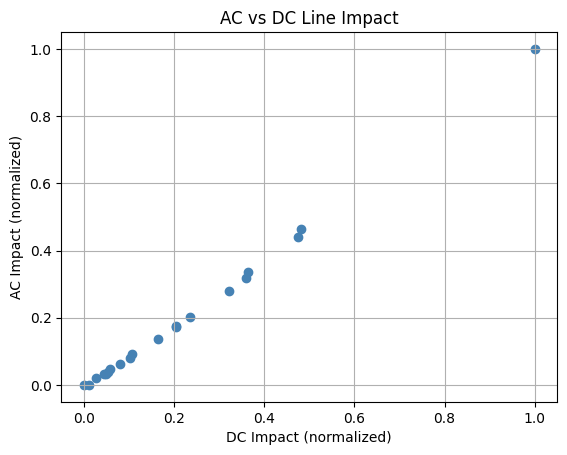

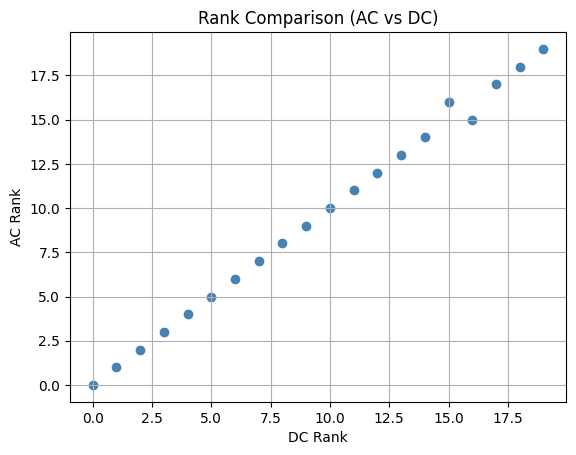

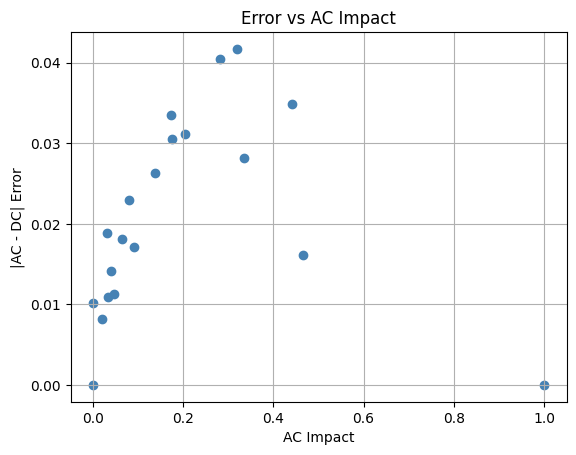

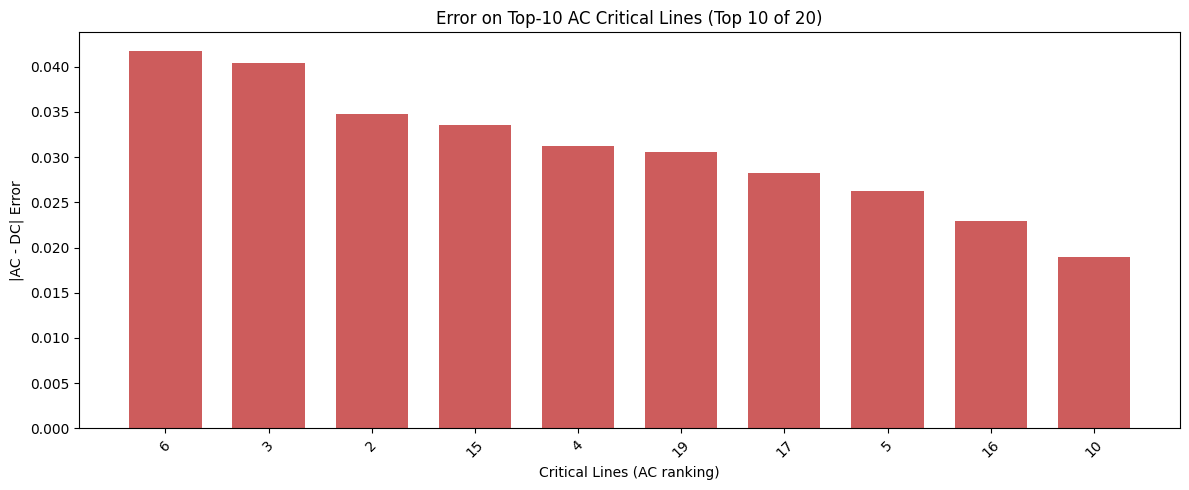


Top 10 Lines with Largest AC vs DC Difference:
Line 6: AC=0.318, DC=0.360, Error=0.042
Line 3: AC=0.281, DC=0.321, Error=0.040
Line 2: AC=0.440, DC=0.475, Error=0.035
Line 15: AC=0.172, DC=0.205, Error=0.034
Line 4: AC=0.203, DC=0.235, Error=0.031
Line 19: AC=0.175, DC=0.205, Error=0.031
Line 17: AC=0.335, DC=0.364, Error=0.028
Line 5: AC=0.138, DC=0.164, Error=0.026
Line 16: AC=0.080, DC=0.103, Error=0.023
Line 10: AC=0.031, DC=0.050, Error=0.019

IEEE-14 Global Metrics (AC vs DC):
Top-10 overlap:            1.00
Spearman Rank Correlation: 0.998
Pearson Correlation:       0.999
MAE:                       0.0207
RMSE:                      0.0240


In [495]:
# calculate flow centrality for both AC and DC power
flow_centrality_ac = compute_flow_centrality(network, G, edges, use_dc=False, normalize=True)
flow_centrality_dc = compute_flow_centrality(network, G, edges, use_dc=True, normalize=True)

# calculate error between AC and DC power flows
error = np.abs(flow_centrality_ac - flow_centrality_dc)

# calculate ranks for AC and DC power flows
rank_ac = flow_centrality_ac.argsort()[::-1].argsort()
rank_dc = flow_centrality_dc.argsort()[::-1].argsort()

# print scatter plots for comparing AC vs DC to analyze how well DC approximates AC for line impact and ranking
plot_scatter(flow_centrality_dc, flow_centrality_ac, xlabel='DC Impact (normalized)', ylabel='AC Impact (normalized)', title='AC vs DC Line Impact')

plot_scatter(rank_dc, rank_ac, xlabel='DC Rank', ylabel='AC Rank', title='Rank Comparison (AC vs DC)')

plot_scatter(flow_centrality_ac, error, xlabel='AC Impact', ylabel='|AC - DC| Error', title='Error vs AC Impact')

# compute top k overlap between AC and DC rankings to see if DC misses critical lines that AC identifies
top_k = 10
top_ac_idx = np.argsort(flow_centrality_ac)[::-1][:top_k]
top_dc_idx = np.argsort(flow_centrality_dc)[::-1][:top_k]

overlap_ac_dc = len(set(top_ac_idx) & set(top_dc_idx)) / top_k

plot_top_k(error, order_by=flow_centrality_ac, xlabel='Critical Lines (AC ranking)', ylabel='|AC - DC| Error', 
           title=f'Error on Top-{top_k} AC Critical Lines', top_k=top_k, color='indianred')

# print top k lines with the largest error between AC and DC
worst_idx = np.argsort(error)[::-1][:top_k]

print(f'\nTop {top_k} Lines with Largest AC vs DC Difference:')
for i in worst_idx:
    print(f'Line {i}: AC={flow_centrality_ac[i]:.3f}, DC={flow_centrality_dc[i]:.3f}, Error={error[i]:.3f}')

# print correlation and error metrics for given network to see how AC and DC compare overall
spearman_corr, _ = spearmanr(flow_centrality_ac, flow_centrality_dc)
pearson_corr, _ = pearsonr(flow_centrality_ac, flow_centrality_dc)
mae = np.mean(error)
rmse = np.sqrt(np.mean(error**2))

# store current network results for later comparison
network_results.append({
    'network': network_name,
    'overlap_ac_dc': overlap_ac_dc,
    'spearman_corr': spearman_corr,
    'pearson_corr': pearson_corr,
    'mae': mae,
    'rmse': rmse
})

# print summaary of results of current network
print(f'\n{network_name} Global Metrics (AC vs DC):')
print(f'Top-{top_k} overlap:            {overlap_ac_dc:.2f}')
print(f'Spearman Rank Correlation: {spearman_corr:.3f}')
print(f'Pearson Correlation:       {pearson_corr:.3f}')
print(f'MAE:                       {mae:.4f}')
print(f'RMSE:                      {rmse:.4f}')

Test IEEE-57 network, 57 buses and 80 branches (links + transformers).

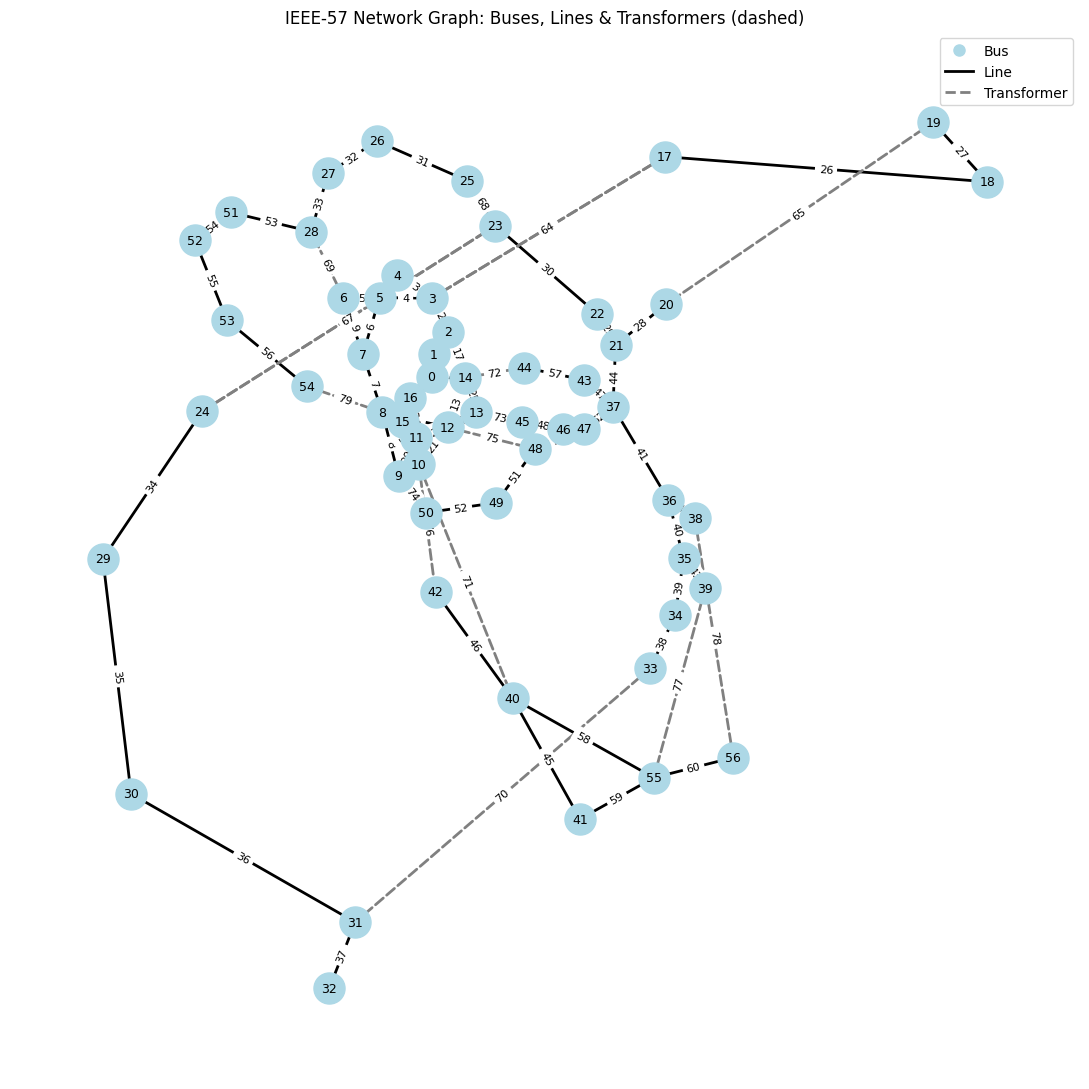

Network baseline:
 [103.22738935  98.89794108  62.09638983  14.20706684  14.85072111
 -16.50731343 -42.6941292  175.87649148  18.05101792  13.32465764
   2.25876972   1.28361187 -14.00261021 -48.020617   149.59687677
  79.58501474  93.68092671  32.94413482   1.06664693 -79.81877707
 -19.49278369 -12.67550962  -2.09878098 -33.70841343 -48.77336265
 -64.78768437   5.39072317   1.90715059  -0.41514423   9.48685757
   3.17161865 -11.10849348 -20.71869215 -25.66755388   7.94106797
   4.1463942   -1.80116932   3.81321978  -7.24639842 -13.30170294
 -15.50229556 -18.34843293   2.72950879   2.05241645  -9.90256871
   9.95529737 -13.03307321 -28.12033156  40.20533652   9.97847344
  -0.95625911   7.24635458 -13.81131215  20.22693259  14.5584312
  -5.66396322  -9.8465519  -40.52491736  -7.17407399  -2.39825264
  -3.97339743  -3.66389596 -10.85711287 -14.2933003  -18.29742287
  -0.41514423  -7.26223612  -6.97883179  11.10849346 -63.25258353
  -7.24639829 -10.91122081 -42.13051244 -40.20533652 -32.4

In [496]:
# test outage simulation on IEEE57 network
network = pn.case57()
network_name = 'IEEE-57'
G, nodes, edges = build_network_graph(network)
print_network_graph(G, title=network_name)

# simulate network outage on edges and get delta_P matrix
DELTA_P, baseline = network_outage_impact(network, G, edges, use_abs=False)

# noirmalize delta_P by baseline to get relative impact of each line outage
DELTA_P_REL = DELTA_P / (np.abs(baseline) + 1e-9)

# print network baseline
print(f'Network baseline:\n {baseline}')

Show heatmap plot of link outage impacts on IEEE-57 network. We can clearly see a few critical lines where removing them causes the power flow to not converge, meaning the system becomes unstable.

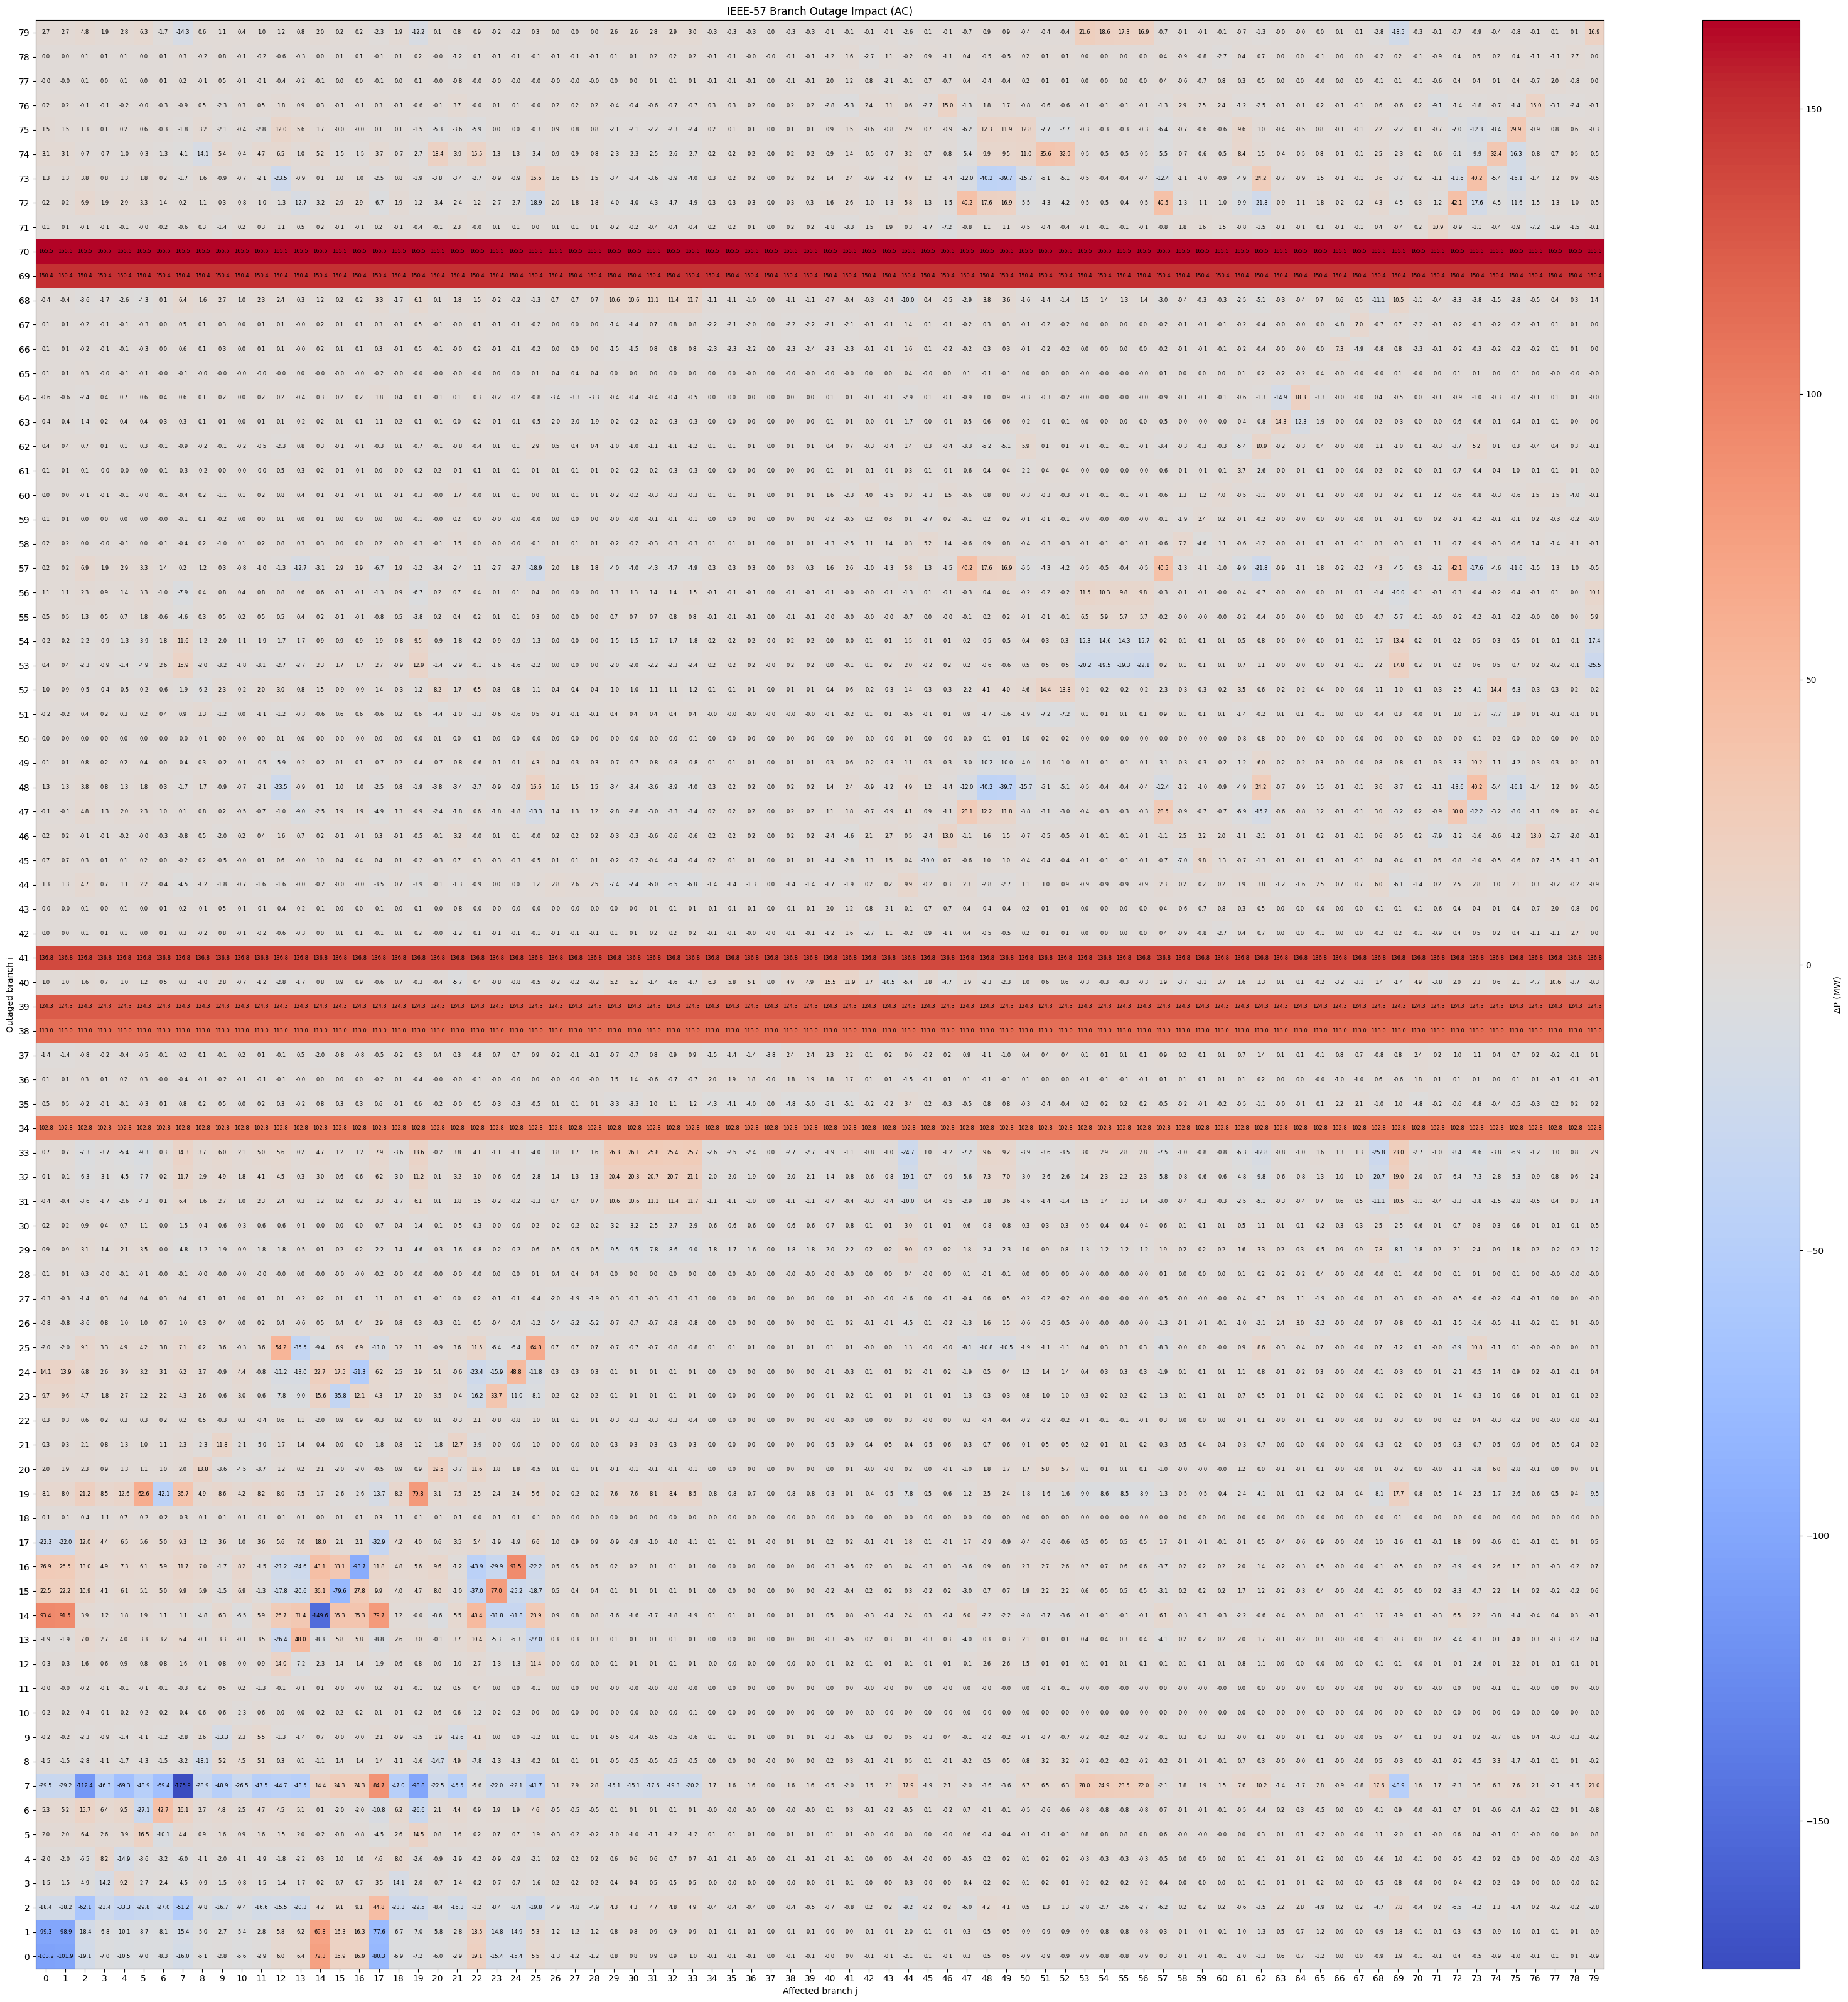

In [497]:
# plot two heatmaps, one for absolute impact and one for relative impact, later choose one that better reflects the network
plot_outage_heatmap(DELTA_P, title=f'{network_name} Branch Outage Impact (AC)')

# plot_outage_heatmap(DELTA_P_REL, title=f'{network_name} Branch Outage Relative Impact (AC)')

Plot top k important links based on their impact on the IEEE-57 network.

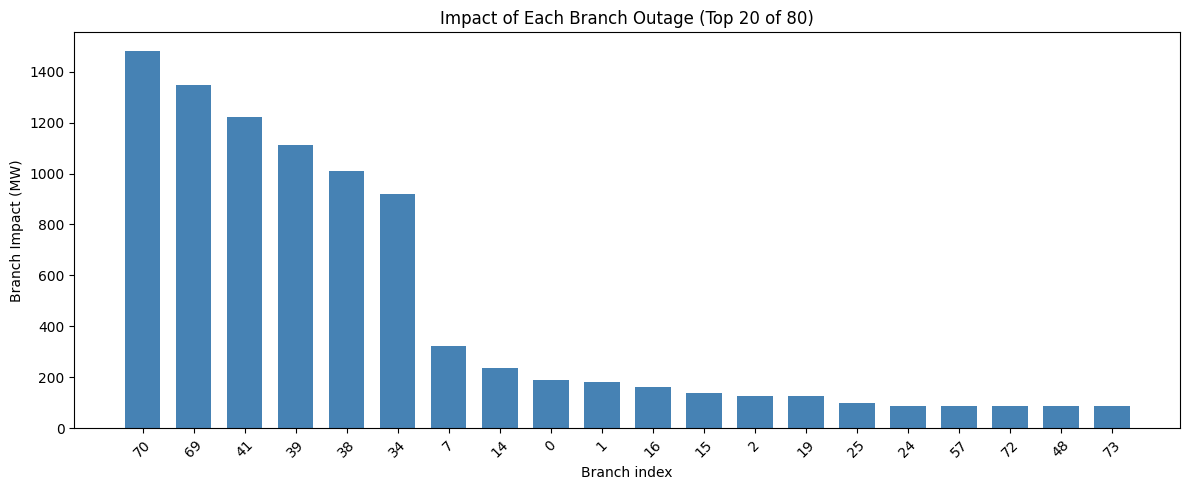

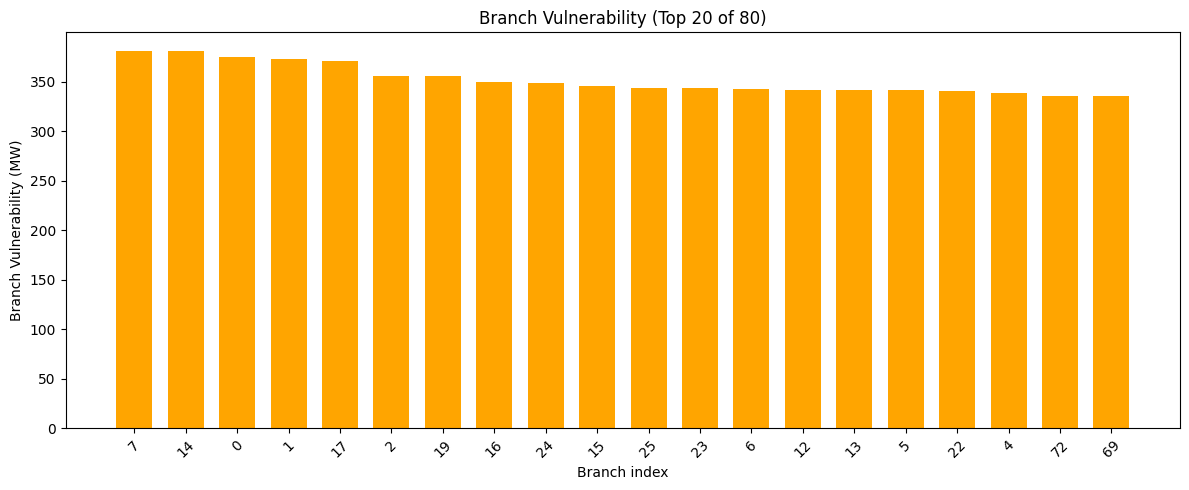

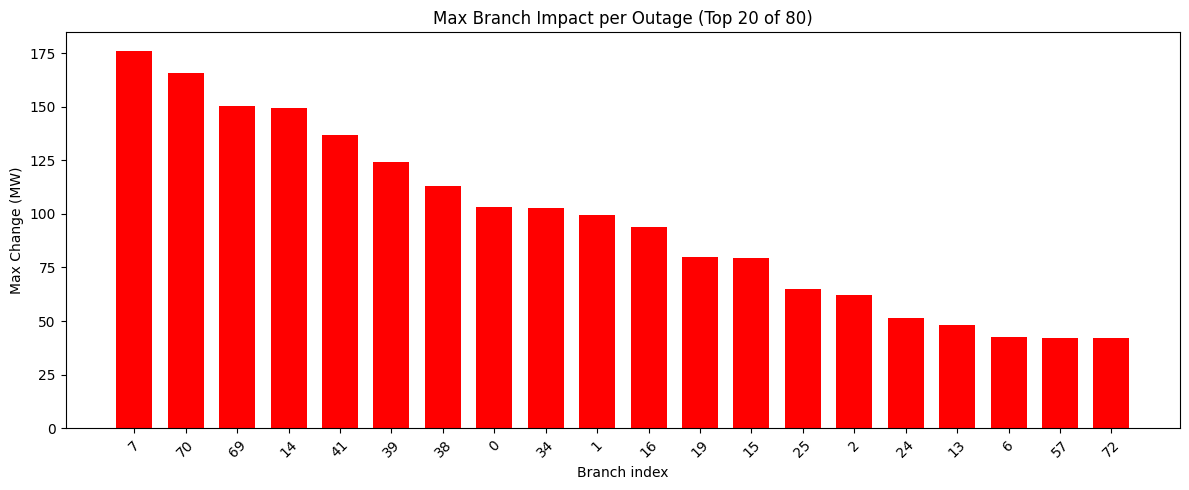

In [498]:

# we compute L2 norm for each row to get overall impact of each branch / link removal from the network
# this gives us single metric for each branch that captures its overall impact
link_impact = np.linalg.norm(DELTA_P, ord=2, axis=1)

# we compute L2 norm for each column to get overall vulnerability of each branch / link to outages in the network
link_vulnerability = np.linalg.norm(DELTA_P, ord=2, axis=0)

# also compute max impact for each branch to compute worst case impact
link_max_impact = np.max(np.abs(DELTA_P), axis=1)

# finally we compute flow centrality by normalizing link impact to get relative importance for each branch in the network
flow_centrality = link_impact / (link_impact.max() + 1e-12)


# plot top k branches by impact, vulnurability and max impact
plot_top_k(link_impact, xlabel='Branch index', ylabel='Branch Impact (MW)', title='Impact of Each Branch Outage', color='steelblue')

plot_top_k(link_vulnerability, xlabel='Branch index', ylabel='Branch Vulnerability (MW)', title='Branch Vulnerability', color='orange')

plot_top_k(link_max_impact, xlabel='Branch index', ylabel='Max Change (MW)', title='Max Branch Impact per Outage', color='red')


Compare topological edge betweenness centrality to your power flow centrality measurement (Physical vs topology).

Edge Betweenness Centrality:
 [0.00250627 0.03258145 0.02130326 0.03508772 0.10651629 0.05137845
 0.07393484 0.08709273 0.03884712 0.12844612 0.10964912 0.13533835
 0.05827068 0.08270677 0.01566416 0.00626566 0.02944862 0.04511278
 0.         0.0093985  0.00501253 0.09461153 0.         0.02882206
 0.05576441 0.01253133 0.12030075 0.11779449 0.10902256 0.04824561
 0.07205514 0.12280702 0.14411028 0.1641604  0.13847118 0.13721805
 0.13471178 0.03508772 0.12218045 0.12593985 0.06140351 0.07957393
 0.00689223 0.08458647 0.07330827 0.02568922 0.03508772 0.04448622
 0.0056391  0.03070175 0.06328321 0.05764411 0.02506266 0.18233083
 0.18859649 0.19486216 0.19987469 0.02067669 0.15601504 0.0093985
 0.06954887 0.13596491 0.         0.12155388 0.         0.11403509
 0.         0.14348371 0.10150376 0.0820802  0.12593985 0.21052632
 0.02443609 0.03822055 0.0112782  0.15162907 0.         0.10714286
 0.03696742 0.20614035]


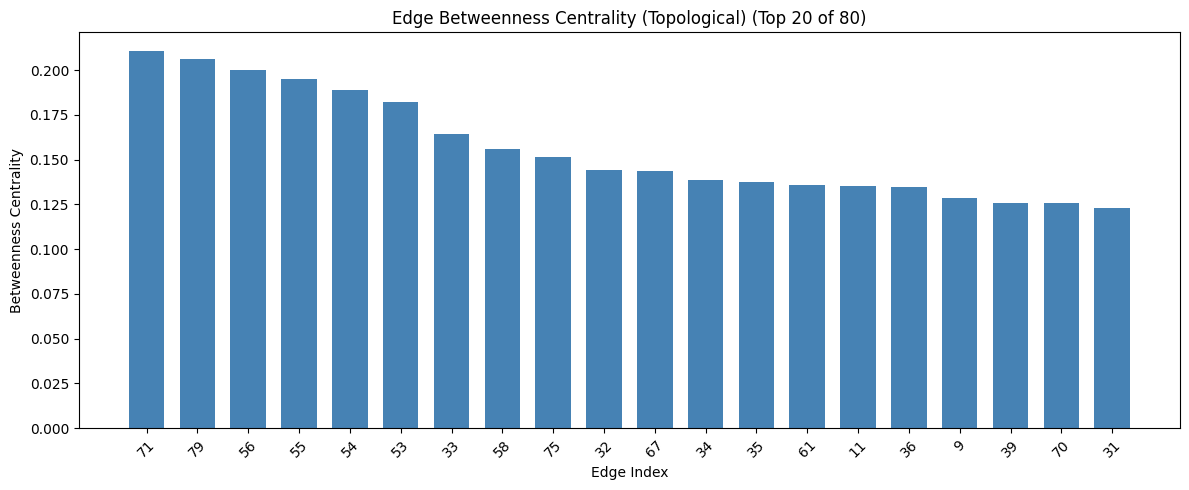

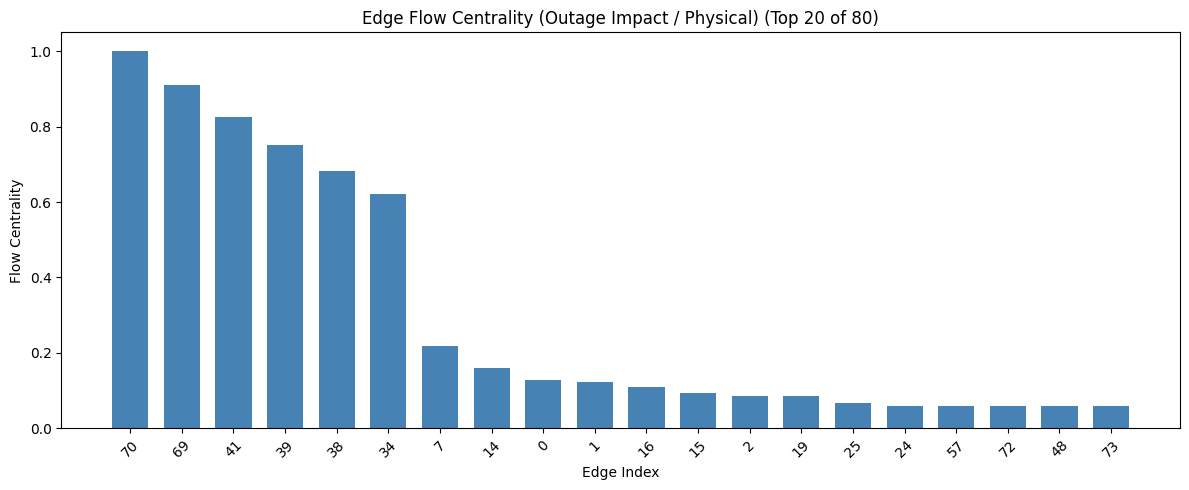

In [499]:
# compute edge betweeness centrality for our network and comapre to flow centrality of outages
edge_betweenness = compute_edge_betweeness(G)
print(f'Edge Betweenness Centrality:\n {edge_betweenness}')


# plot edge betweeness and flow for comparison between topological and physical centrtality measures
plot_top_k(edge_betweenness, title='Edge Betweenness Centrality (Topological)', xlabel='Edge Index', ylabel='Betweenness Centrality', color='steelblue')

plot_top_k(flow_centrality, title='Edge Flow Centrality (Outage Impact / Physical)', xlabel='Edge Index', ylabel='Flow Centrality', color='steelblue')


We compare the relationship between edge betweenness and flow centrality. On the IEEE-57 network the correlation between edge betweenness and physical flow is weak.

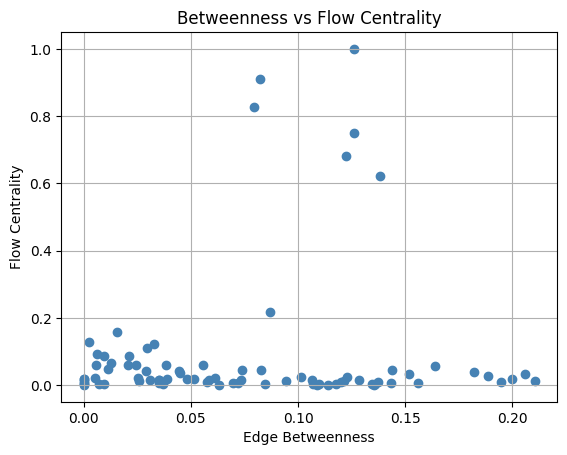

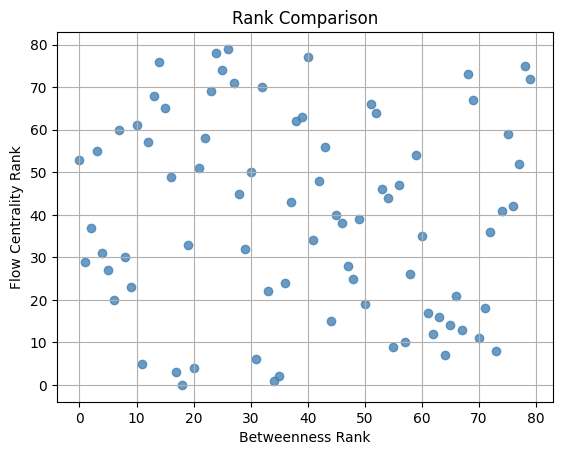

In [500]:
# print scatter plot comparing edge betweenness and flow centrality
plot_scatter(edge_betweenness, flow_centrality, xlabel='Edge Betweenness', ylabel='Flow Centrality', title='Betweenness vs Flow Centrality')

# print scatter plot comparing edge betweenness and flow centrality ranks
rank_flow = np.argsort(np.argsort(flow_centrality)[::-1])
rank_betw = np.argsort(np.argsort(edge_betweenness)[::-1])
plot_scatter(rank_betw, rank_flow, xlabel='Betweenness Rank', ylabel='Flow Centrality Rank', title='Rank Comparison', alpha=0.8)


Comparing AC vs DC power flow for link on IEEE-57 network. 

For the IEEE-57 network, the DC approximation generally agrees with AC in terms of critical line rankings, but the impact values differ more significantly. 

This suggests that for larger networks like IEEE-57, the DC model may not be as accurate in estimating line outage impacts compared to smaller networks like IEEE-14.

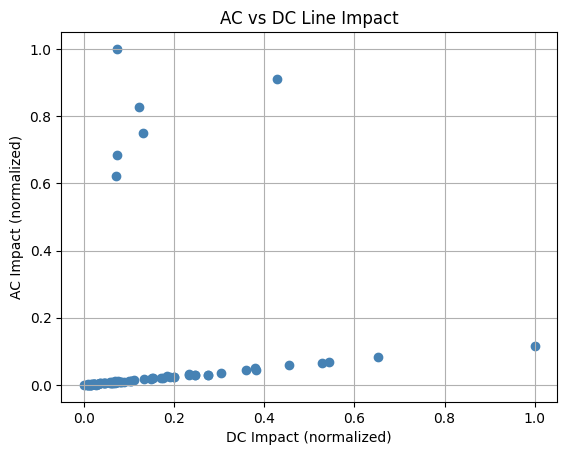

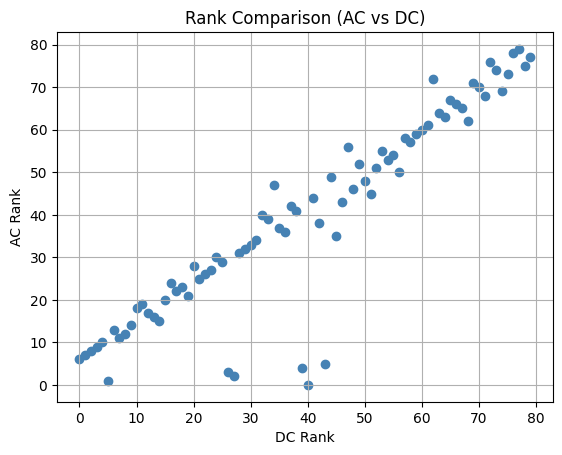

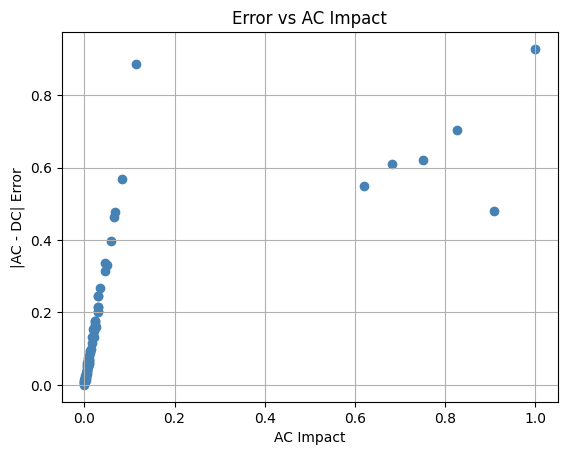

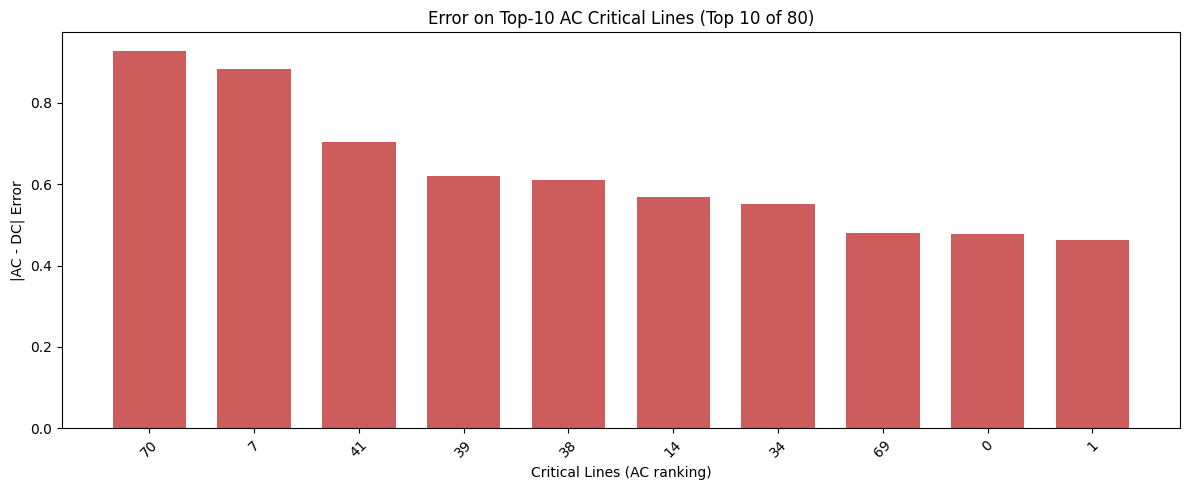


Top 10 Lines with Largest AC vs DC Difference:
Line 70: AC=1.000, DC=0.073, Error=0.927
Line 7: AC=0.115, DC=1.000, Error=0.885
Line 41: AC=0.826, DC=0.123, Error=0.703
Line 39: AC=0.751, DC=0.131, Error=0.621
Line 38: AC=0.683, DC=0.073, Error=0.610
Line 14: AC=0.084, DC=0.652, Error=0.568
Line 34: AC=0.621, DC=0.070, Error=0.550
Line 69: AC=0.909, DC=0.428, Error=0.481
Line 0: AC=0.067, DC=0.544, Error=0.477
Line 1: AC=0.065, DC=0.528, Error=0.463

IEEE-57 Global Metrics (AC vs DC):
Top-10 overlap:            0.50
Spearman Rank Correlation: 0.917
Pearson Correlation:       0.126
MAE:                       0.1600
RMSE:                      0.2595


In [501]:
# calculate flow centrality for both AC and DC power
flow_centrality_ac = compute_flow_centrality(network, G, edges, use_dc=False, normalize=True)
flow_centrality_dc = compute_flow_centrality(network, G, edges, use_dc=True, normalize=True)

# calculate error between AC and DC power flows
error = np.abs(flow_centrality_ac - flow_centrality_dc)

# calculate ranks for AC and DC power flows
rank_ac = flow_centrality_ac.argsort()[::-1].argsort()
rank_dc = flow_centrality_dc.argsort()[::-1].argsort()

# print scatter plots for comparing AC vs DC to analyze how well DC approximates AC for line impact and ranking
plot_scatter(flow_centrality_dc, flow_centrality_ac, xlabel='DC Impact (normalized)', ylabel='AC Impact (normalized)', title='AC vs DC Line Impact')

plot_scatter(rank_dc, rank_ac, xlabel='DC Rank', ylabel='AC Rank', title='Rank Comparison (AC vs DC)')

plot_scatter(flow_centrality_ac, error, xlabel='AC Impact', ylabel='|AC - DC| Error', title='Error vs AC Impact')

# compute top k overlap between AC and DC rankings to see if DC misses critical lines that AC identifies
top_k = 10
top_ac_idx = np.argsort(flow_centrality_ac)[::-1][:top_k]
top_dc_idx = np.argsort(flow_centrality_dc)[::-1][:top_k]

overlap_ac_dc = len(set(top_ac_idx) & set(top_dc_idx)) / top_k

plot_top_k(error, order_by=flow_centrality_ac, xlabel='Critical Lines (AC ranking)', ylabel='|AC - DC| Error', 
           title=f'Error on Top-{top_k} AC Critical Lines', top_k=top_k, color='indianred')

# print top k lines with the largest error between AC and DC
worst_idx = np.argsort(error)[::-1][:top_k]

print(f'\nTop {top_k} Lines with Largest AC vs DC Difference:')
for i in worst_idx:
    print(f'Line {i}: AC={flow_centrality_ac[i]:.3f}, DC={flow_centrality_dc[i]:.3f}, Error={error[i]:.3f}')

# print correlation and error metrics for given network to see how AC and DC compare overall
spearman_corr, _ = spearmanr(flow_centrality_ac, flow_centrality_dc)
pearson_corr, _ = pearsonr(flow_centrality_ac, flow_centrality_dc)
mae = np.mean(error)
rmse = np.sqrt(np.mean(error**2))

# store current network results for later comparison
network_results.append({
    'network': network_name,
    'overlap_ac_dc': overlap_ac_dc,
    'spearman_corr': spearman_corr,
    'pearson_corr': pearson_corr,
    'mae': mae,
    'rmse': rmse
})

# print summaary of results of current network
print(f'\n{network_name} Global Metrics (AC vs DC):')
print(f'Top-{top_k} overlap:            {overlap_ac_dc:.2f}')
print(f'Spearman Rank Correlation: {spearman_corr:.3f}')
print(f'Pearson Correlation:       {pearson_corr:.3f}')
print(f'MAE:                       {mae:.4f}')
print(f'RMSE:                      {rmse:.4f}')

Test IEEE-118 network, 118 buses and 186 branches (links + transformers).

In [502]:
# test outage simulation on IEEE118 network
network = pn.case118()
network_name = 'IEEE-118'
G, nodes, edges = build_network_graph(network)
# print_network_graph(G, title=network_name)

# simulate network outage on edges and get delta_P matrix
DELTA_P, baseline = network_outage_impact(network, G, edges, use_abs=False)

# noirmalize delta_P by baseline to get relative impact of each line outage
DELTA_P_REL = DELTA_P / (np.abs(baseline) + 1e-9)

# print network baseline
print(f'Network baseline:\n {baseline}')

Network baseline:
 [-1.23530818e+01 -3.86469182e+01 -1.03228544e+02 -6.81098842e+01
  8.84692046e+01  3.55387448e+01 -4.40635012e+02 -4.45254650e+02
  6.42285441e+01  7.72233028e+01  3.42929306e+01 -3.24506905e+01
 -9.78712522e+00  1.64786469e+01  3.50844120e+01  1.83135483e+01
  7.67384558e-01  4.23726873e+00  7.50506394e+00 -1.03867429e+02
 -1.75133175e+01  8.02719476e+01  1.93913784e+01 -1.06481043e+01
  1.15178390e+01 -2.86906773e+01 -4.28616963e+01 -5.32805180e+01
  8.14059776e+00 -1.62494069e+02  1.43529071e+02  3.28833438e+01
  1.56625501e+01  7.41647379e+01  2.23778713e+02  1.47409163e+01
 -8.40799784e+00  9.30304007e+01 -2.98745629e+01  1.25248131e+01
  7.32300963e+00 -3.57316686e+00  8.36486186e-01 -3.38364862e+01
 -1.57020942e+01  3.02484630e+01 -9.42861444e+01  5.49076725e+01
  4.40198121e+01  6.24549154e+01  2.69155125e+01  1.54462697e+01
 -1.18374729e+01 -2.15909800e+01 -1.65979299e+01  1.40869543e+00
 -3.27749300e+01 -3.63423617e+01 -3.11421669e+01 -1.47447473e+01
 -9.40

Show heatmap plot of link outage impacts on IEEE-118 network.

In [503]:
# plot two heatmaps, one for absolute impact and one for relative impact, later choose one that better reflects the network
# plot_outage_heatmap(DELTA_P, title=f'{network_name} Branch Outage Impact (AC)')

# plot_outage_heatmap(DELTA_P_REL, title=f'{network_name} Branch Outage Relative Impact (AC)')

Plot top k important links based on their impact on the IEEE-118 network.

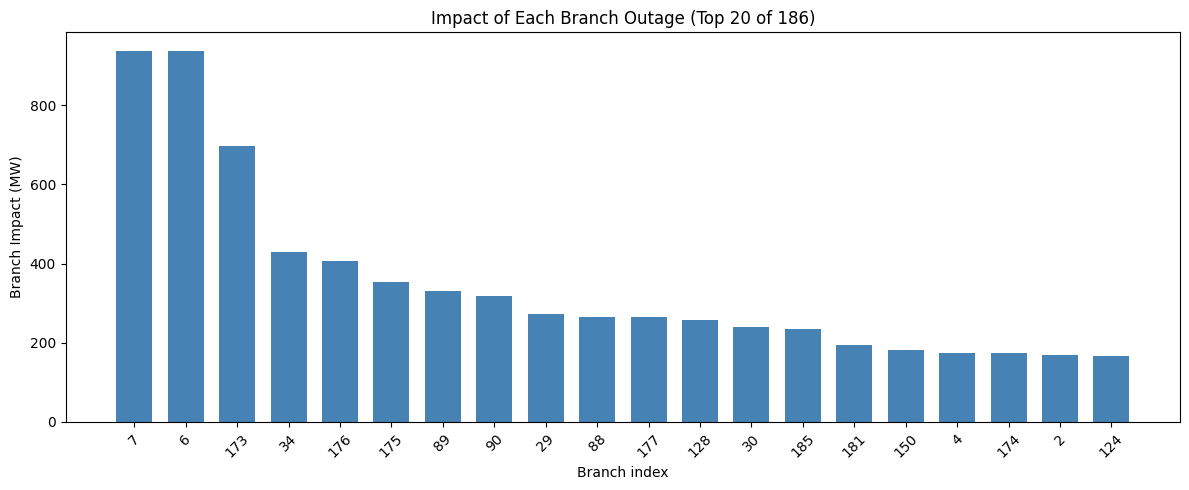

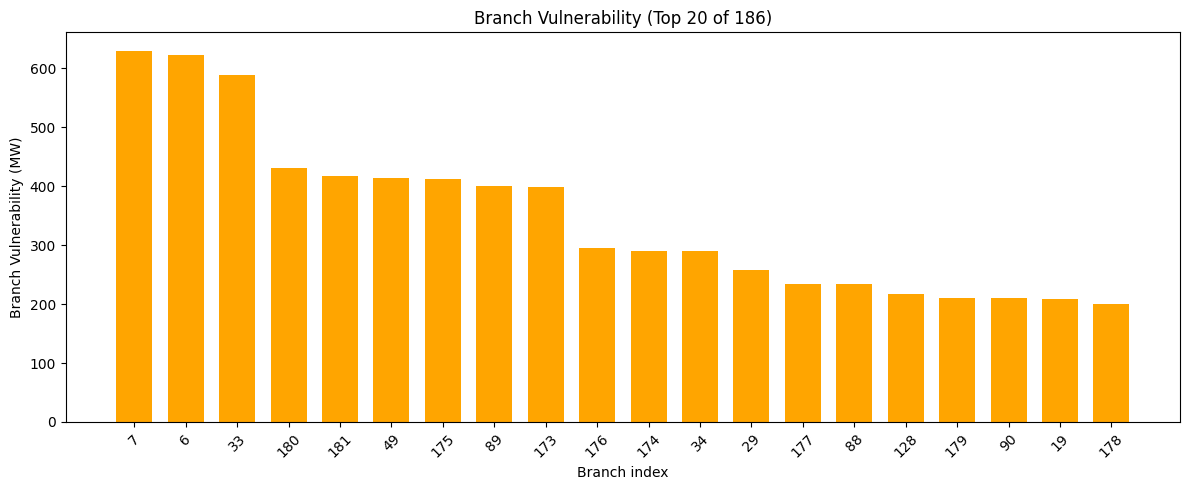

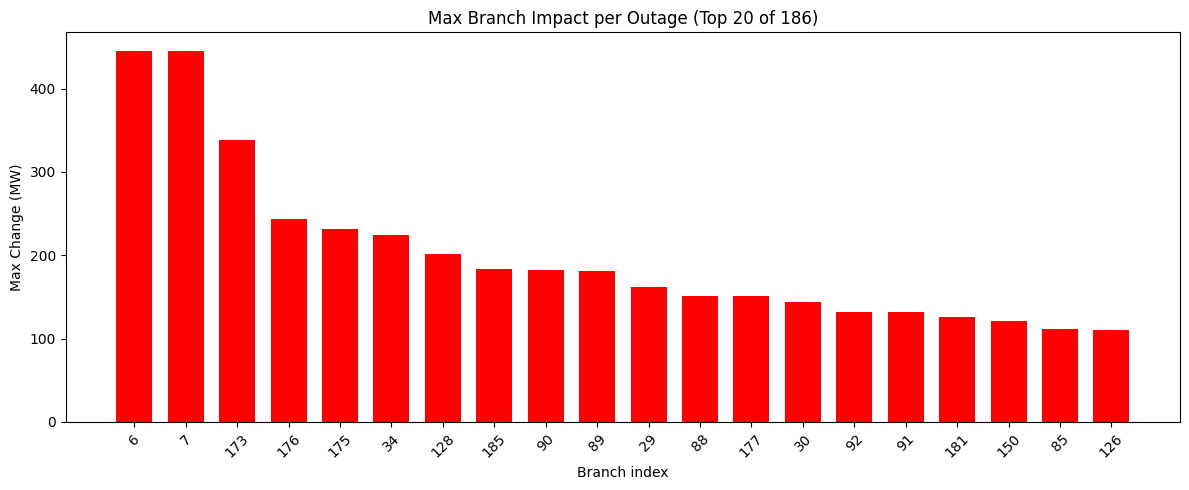

In [504]:

# we compute L2 norm for each row to get overall impact of each branch / link removal from the network
# this gives us single metric for each branch that captures its overall impact
link_impact = np.linalg.norm(DELTA_P, ord=2, axis=1)

# we compute L2 norm for each column to get overall vulnerability of each branch / link to outages in the network
link_vulnerability = np.linalg.norm(DELTA_P, ord=2, axis=0)

# also compute max impact for each branch to compute worst case impact
link_max_impact = np.max(np.abs(DELTA_P), axis=1)

# finally we compute flow centrality by normalizing link impact to get relative importance for each branch in the network
flow_centrality = link_impact / (link_impact.max() + 1e-12)


# plot top k branches by impact, vulnurability and max impact
plot_top_k(link_impact, xlabel='Branch index', ylabel='Branch Impact (MW)', title='Impact of Each Branch Outage', color='steelblue')

plot_top_k(link_vulnerability, xlabel='Branch index', ylabel='Branch Vulnerability (MW)', title='Branch Vulnerability', color='orange')

plot_top_k(link_max_impact, xlabel='Branch index', ylabel='Max Change (MW)', title='Max Branch Impact per Outage', color='red')


Compare topological edge betweenness centrality to your power flow centrality measurement (Physical vs topology).

Edge Betweenness Centrality:
 [2.89729103e-03 1.40518615e-02 0.00000000e+00 3.30291178e-02
 1.68042880e-02 1.44864552e-04 3.36085760e-02 1.69491525e-02
 1.69491525e-02 3.10010141e-02 0.00000000e+00 1.95567145e-02
 6.08431117e-03 1.68042880e-02 3.18702014e-03 8.69187310e-03
 1.89772563e-02 2.30334637e-02 5.63523106e-02 2.89729103e-03
 7.12733594e-02 1.85426626e-02 4.49080110e-03 1.82529335e-02
 1.11545705e-02 9.41619586e-03 2.25988701e-02 3.75199189e-02
 4.02723454e-02 2.50615674e-02 6.31609445e-02 3.20150659e-02
 1.53556425e-02 1.29798638e-01 1.01839780e-01 5.28755614e-02
 1.59351007e-03 1.23134869e-02 3.83891062e-02 2.17296827e-03
 4.25901782e-02 3.31739823e-02 0.00000000e+00 1.69491525e-02
 5.51933942e-02 1.69491525e-02 0.00000000e+00 1.69491525e-02
 4.98334058e-02 3.16384181e-01 0.00000000e+00 0.00000000e+00
 5.34550196e-02 1.69491525e-02 6.31609445e-02 5.22961031e-02
 7.51847023e-02 1.79632044e-02 1.56453716e-02 1.69491525e-02
 0.00000000e+00 3.25220918e-02 3.25220918e-02 1.0256410

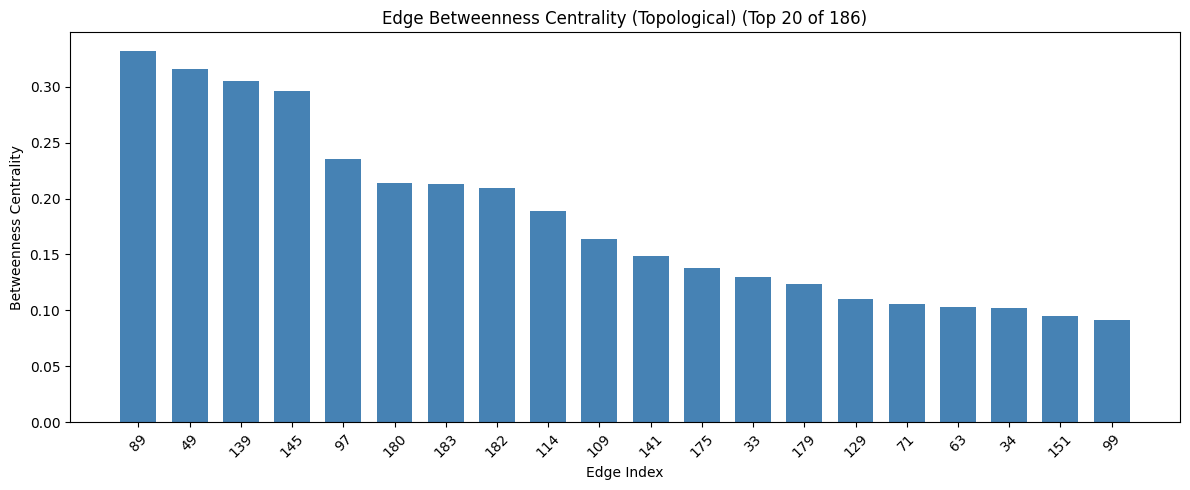

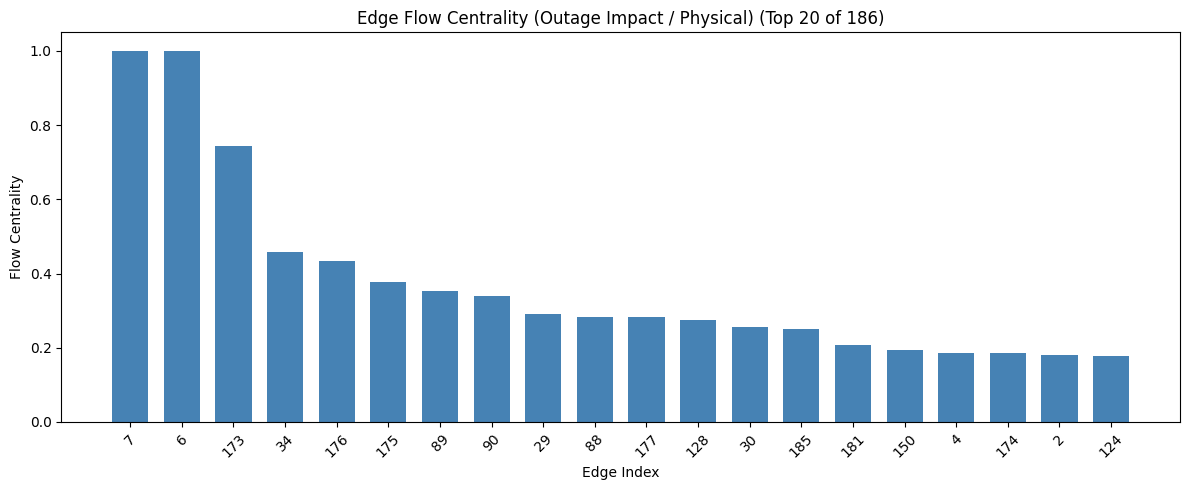

In [505]:
# compute edge betweeness centrality for our network and comapre to flow centrality of outages
edge_betweenness = compute_edge_betweeness(G)
print(f'Edge Betweenness Centrality:\n {edge_betweenness}')


# plot edge betweeness and flow for comparison between topological and physical centrtality measures
plot_top_k(edge_betweenness, title='Edge Betweenness Centrality (Topological)', xlabel='Edge Index', ylabel='Betweenness Centrality', color='steelblue')

plot_top_k(flow_centrality, title='Edge Flow Centrality (Outage Impact / Physical)', xlabel='Edge Index', ylabel='Flow Centrality', color='steelblue')


We compare the relationship between edge betweenness and flow centrality. On the IEEE-118 network the correlation between edge betweenness and physical flow is weak.

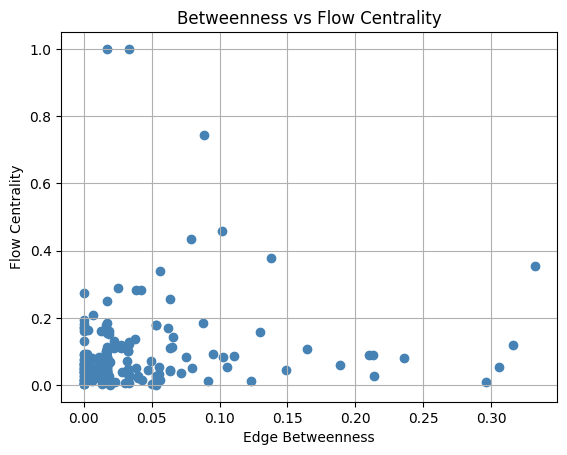

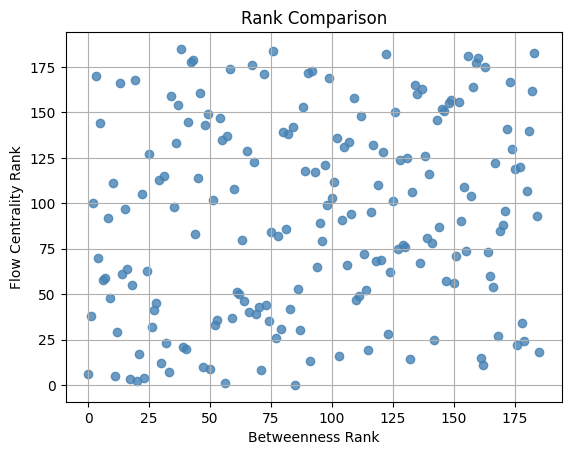

In [506]:
# print scatter plot comparing edge betweenness and flow centrality
plot_scatter(edge_betweenness, flow_centrality, xlabel='Edge Betweenness', ylabel='Flow Centrality', title='Betweenness vs Flow Centrality')

# print scatter plot comparing edge betweenness and flow centrality ranks
rank_flow = np.argsort(np.argsort(flow_centrality)[::-1])
rank_betw = np.argsort(np.argsort(edge_betweenness)[::-1])
plot_scatter(rank_betw, rank_flow, xlabel='Betweenness Rank', ylabel='Flow Centrality Rank', title='Rank Comparison', alpha=0.8)


Comparing AC vs DC power flow for link on IEEE-118 network. 

For the IEEE-118 network, the DC approximation matches the AC results very closely. Both the ranking of critical lines and the impact magnitudes show strong agreement. 

This indicates that DC provides a highly accurate approximation of AC for outage impact analysis for this network.


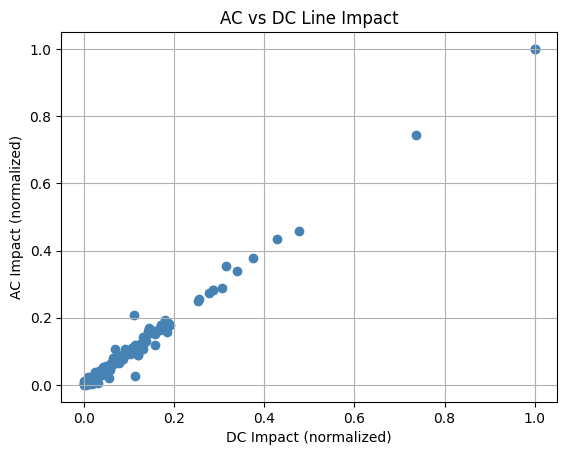

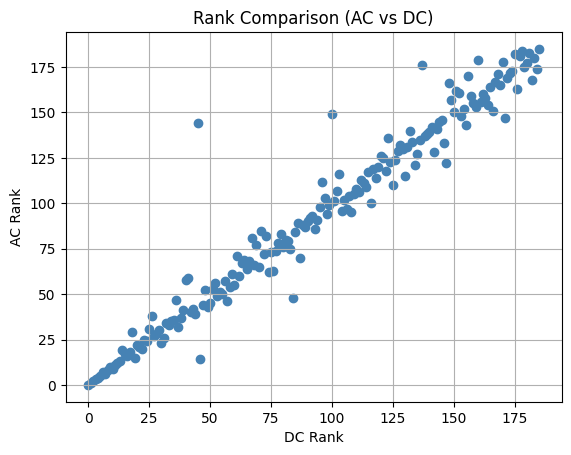

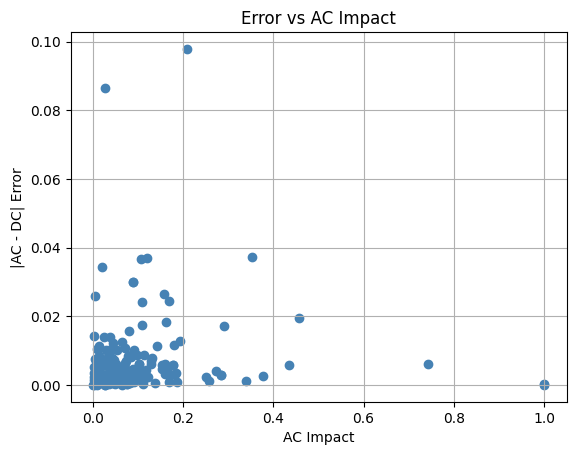

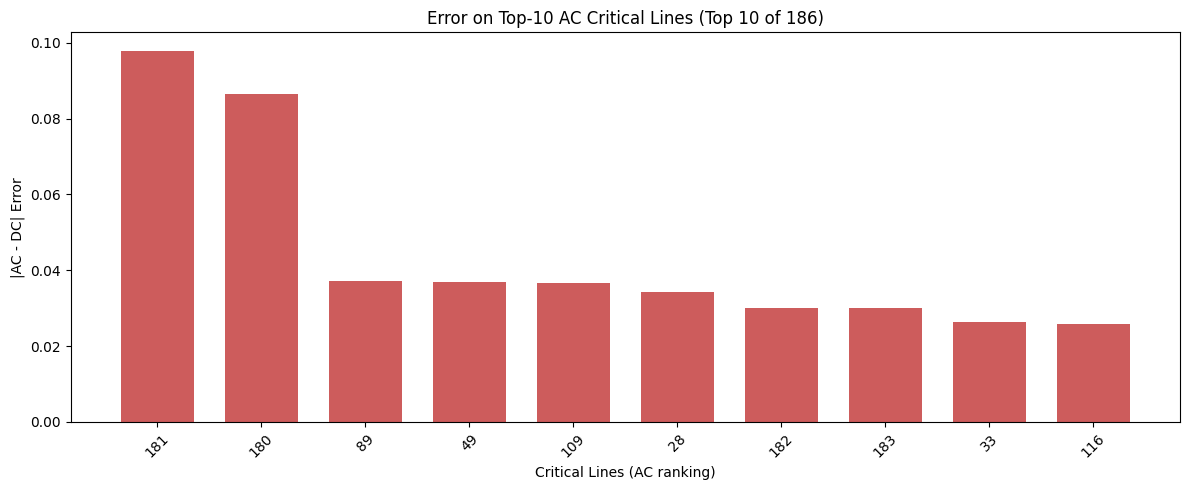


Top 10 Lines with Largest AC vs DC Difference:
Line 181: AC=0.208, DC=0.110, Error=0.098
Line 180: AC=0.027, DC=0.113, Error=0.086
Line 89: AC=0.354, DC=0.316, Error=0.037
Line 49: AC=0.120, DC=0.157, Error=0.037
Line 109: AC=0.106, DC=0.069, Error=0.037
Line 28: AC=0.021, DC=0.055, Error=0.034
Line 182: AC=0.090, DC=0.120, Error=0.030
Line 183: AC=0.090, DC=0.120, Error=0.030
Line 33: AC=0.158, DC=0.184, Error=0.026
Line 116: AC=0.005, DC=0.031, Error=0.026

IEEE-118 Global Metrics (AC vs DC):
Top-10 overlap:            0.90
Spearman Rank Correlation: 0.976
Pearson Correlation:       0.995
MAE:                       0.0066
RMSE:                      0.0133


In [507]:
# calculate flow centrality for both AC and DC power
flow_centrality_ac = compute_flow_centrality(network, G, edges, use_dc=False, normalize=True)
flow_centrality_dc = compute_flow_centrality(network, G, edges, use_dc=True, normalize=True)

# calculate error between AC and DC power flows
error = np.abs(flow_centrality_ac - flow_centrality_dc)

# calculate ranks for AC and DC power flows
rank_ac = flow_centrality_ac.argsort()[::-1].argsort()
rank_dc = flow_centrality_dc.argsort()[::-1].argsort()

# print scatter plots for comparing AC vs DC to analyze how well DC approximates AC for line impact and ranking
plot_scatter(flow_centrality_dc, flow_centrality_ac, xlabel='DC Impact (normalized)', ylabel='AC Impact (normalized)', title='AC vs DC Line Impact')

plot_scatter(rank_dc, rank_ac, xlabel='DC Rank', ylabel='AC Rank', title='Rank Comparison (AC vs DC)')

plot_scatter(flow_centrality_ac, error, xlabel='AC Impact', ylabel='|AC - DC| Error', title='Error vs AC Impact')

# compute top k overlap between AC and DC rankings to see if DC misses critical lines that AC identifies
top_k = 10
top_ac_idx = np.argsort(flow_centrality_ac)[::-1][:top_k]
top_dc_idx = np.argsort(flow_centrality_dc)[::-1][:top_k]

overlap_ac_dc = len(set(top_ac_idx) & set(top_dc_idx)) / top_k

plot_top_k(error, order_by=flow_centrality_ac, xlabel='Critical Lines (AC ranking)', ylabel='|AC - DC| Error', 
           title=f'Error on Top-{top_k} AC Critical Lines', top_k=top_k, color='indianred')

# print top k lines with the largest error between AC and DC
worst_idx = np.argsort(error)[::-1][:top_k]

print(f'\nTop {top_k} Lines with Largest AC vs DC Difference:')
for i in worst_idx:
    print(f'Line {i}: AC={flow_centrality_ac[i]:.3f}, DC={flow_centrality_dc[i]:.3f}, Error={error[i]:.3f}')

# print correlation and error metrics for given network to see how AC and DC compare overall
spearman_corr, _ = spearmanr(flow_centrality_ac, flow_centrality_dc)
pearson_corr, _ = pearsonr(flow_centrality_ac, flow_centrality_dc)
mae = np.mean(error)
rmse = np.sqrt(np.mean(error**2))

# store current network results for later comparison
network_results.append({
    'network': network_name,
    'overlap_ac_dc': overlap_ac_dc,
    'spearman_corr': spearman_corr,
    'pearson_corr': pearson_corr,
    'mae': mae,
    'rmse': rmse
})

# print summaary of results of current network
print(f'\n{network_name} Global Metrics (AC vs DC):')
print(f'Top-{top_k} overlap:            {overlap_ac_dc:.2f}')
print(f'Spearman Rank Correlation: {spearman_corr:.3f}')
print(f'Pearson Correlation:       {pearson_corr:.3f}')
print(f'MAE:                       {mae:.4f}')
print(f'RMSE:                      {rmse:.4f}')

Test IEEE-300 network, 300 buses and 411 branches (links + transformers).

In [508]:
# test outage simulation on IEEE300 network
network = pn.case300()
network_name = 'IEEE-300'
G, nodes, edges = build_network_graph(network)
# print_network_graph(G, title=network_name)

# simulate network outage on edges and get delta_P matrix
DELTA_P, baseline = network_outage_impact(network, G, edges, use_abs=False)

# noirmalize delta_P by baseline to get relative impact of each line outage
DELTA_P_REL = DELTA_P / (np.abs(baseline) + 1e-9)

# print network baseline
print(f'Network baseline:\n {baseline}')

Network baseline:
 [ 3.63050450e+01  9.45716496e+00  8.38306913e+00  8.38306913e+00
  6.52429558e+00  6.52429558e+00  7.35330988e+00  9.52281204e-01
  7.26010570e+00  4.40405113e+00  4.38597314e+00  3.83990355e+00
  4.04322635e+02  1.51988568e+02  3.78918593e+02  2.78352898e+02
  1.45381182e+02  9.47780453e+01  6.76660397e+02  1.23293192e+02
  1.91002522e+02  4.55053119e+01 -4.28807015e+00  3.12160751e+02
  2.63590162e+01  1.52849844e+02  4.29710446e+02  9.29959220e+01
  1.39634897e+02  1.80568395e+01  1.40891794e+01  1.27298280e+01
  3.88462944e+02 -5.42990306e+01  1.97962534e+02 -1.51500986e+01
  2.43037044e+01 -2.27327425e+02 -9.62629777e+01  1.26480569e+02
  1.16776096e+02  7.86947286e+01  4.60877563e+01  2.47653239e+00
  8.54014888e+01  4.62093514e+01 -6.83951932e+01 -1.18215647e+02
  4.90033188e+01  1.15663961e+02 -4.77025835e+01 -1.16964697e+02
  5.06485027e+01  4.01092880e+01 -4.24024268e+01 -1.93181548e+02
 -2.01635331e+00 -1.51928816e-01 -1.05799350e+02  8.64397712e+01
  5.00

Show heatmap plot of link outage impacts on IEEE-300 network.

In [509]:
# plot two heatmaps, one for absolute impact and one for relative impact, later choose one that better reflects the network
# plot_outage_heatmap(DELTA_P, title=f'{network_name} Branch Outage Impact (AC)')

# plot_outage_heatmap(DELTA_P_REL, title=f'{network_name} Branch Outage Relative Impact (AC)')

Plot top k important links based on their impact on the IEEE-300 network.

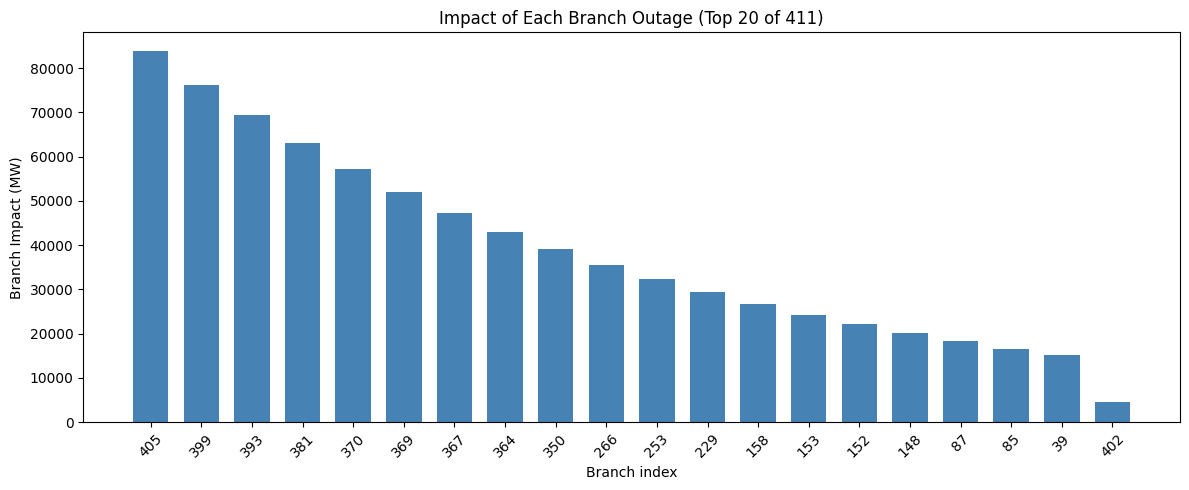

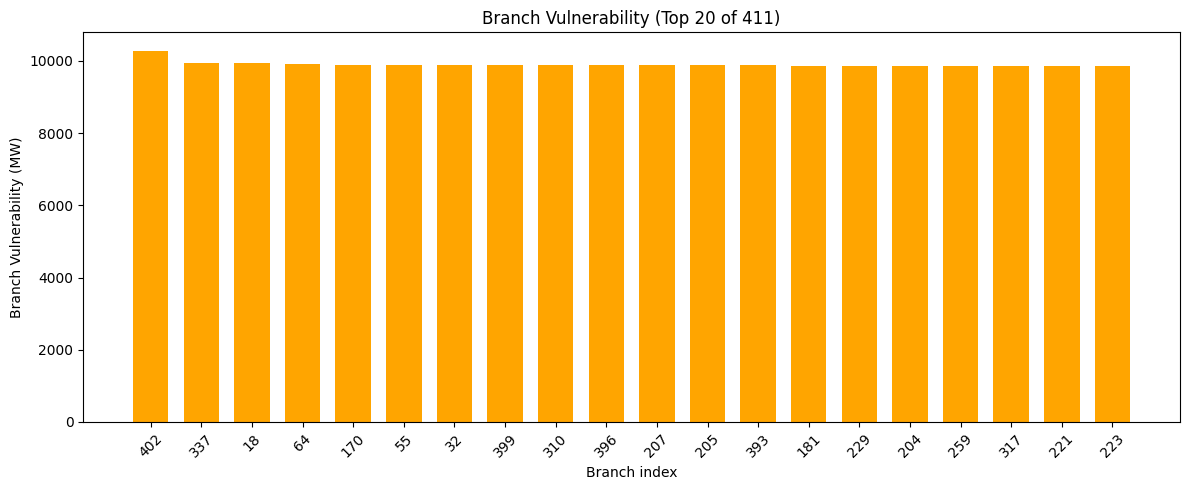

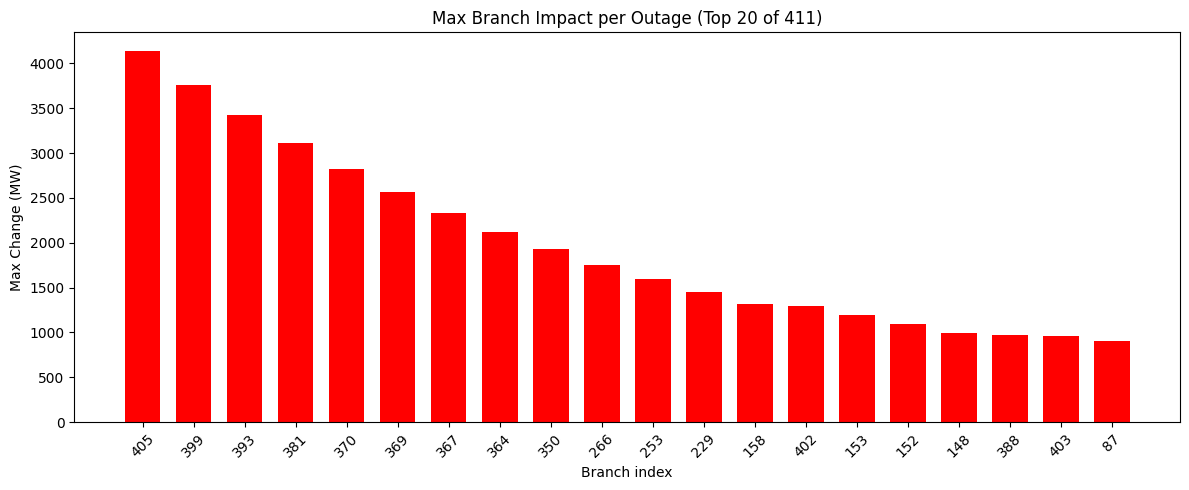

In [510]:

# we compute L2 norm for each row to get overall impact of each branch / link removal from the network
# this gives us single metric for each branch that captures its overall impact
link_impact = np.linalg.norm(DELTA_P, ord=2, axis=1)

# we compute L2 norm for each column to get overall vulnerability of each branch / link to outages in the network
link_vulnerability = np.linalg.norm(DELTA_P, ord=2, axis=0)

# also compute max impact for each branch to compute worst case impact
link_max_impact = np.max(np.abs(DELTA_P), axis=1)

# finally we compute flow centrality by normalizing link impact to get relative importance for each branch in the network
flow_centrality = link_impact / (link_impact.max() + 1e-12)


# plot top k branches by impact, vulnurability and max impact
plot_top_k(link_impact, xlabel='Branch index', ylabel='Branch Impact (MW)', title='Impact of Each Branch Outage', color='steelblue')

plot_top_k(link_vulnerability, xlabel='Branch index', ylabel='Branch Vulnerability (MW)', title='Branch Vulnerability', color='orange')

plot_top_k(link_max_impact, xlabel='Branch index', ylabel='Max Change (MW)', title='Max Branch Impact per Outage', color='red')


Compare topological edge betweenness centrality to your power flow centrality measurement (Physical vs topology).

Edge Betweenness Centrality:
 [4.57302118e-02 1.89297659e-02 4.41694537e-02 4.41694537e-02
 2.28651059e-02 2.28651059e-02 3.28874025e-02 1.98662207e-02
 9.36454849e-04 3.28874025e-02 2.63991081e-02 6.66666667e-03
 0.00000000e+00 0.00000000e+00 2.89855072e-03 0.00000000e+00
 1.48896321e-01 1.74559643e-01 5.42697882e-02 1.85061315e-03
 2.23857302e-02 1.50724638e-02 7.58082497e-04 3.50055741e-03
 4.81605351e-03 1.51616499e-03 4.48383501e-02 5.15050167e-03
 9.63210702e-03 1.40401338e-01 7.86176143e-02 3.23522854e-02
 2.71661093e-01 1.20624303e-01 2.34626533e-01 1.11482720e-04
 1.97547380e-02 4.54180602e-02 6.55518395e-03 6.64437012e-03
 6.66666667e-03 2.00668896e-04 1.32218506e-02 6.66666667e-03
 0.00000000e+00 1.33779264e-04 0.00000000e+00 1.31549610e-02
 5.75250836e-03 0.00000000e+00 0.00000000e+00 1.62318841e-02
 2.80936455e-03 7.53623188e-03 0.00000000e+00 1.14604236e-02
 7.52062430e-02 0.00000000e+00 1.18171683e-03 2.72017837e-03
 1.32887402e-02 6.48829431e-03 6.51059086e-03 6.7335563

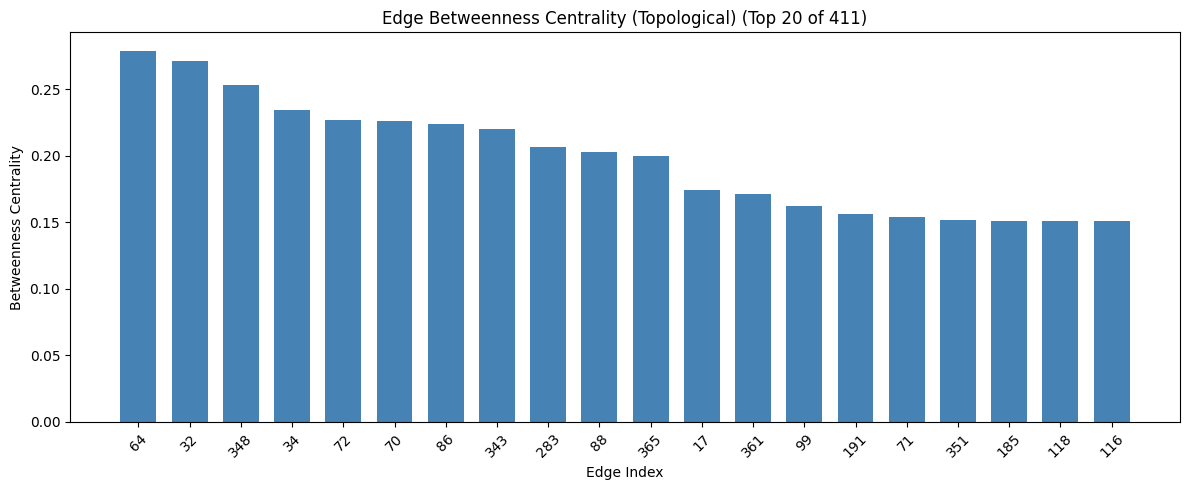

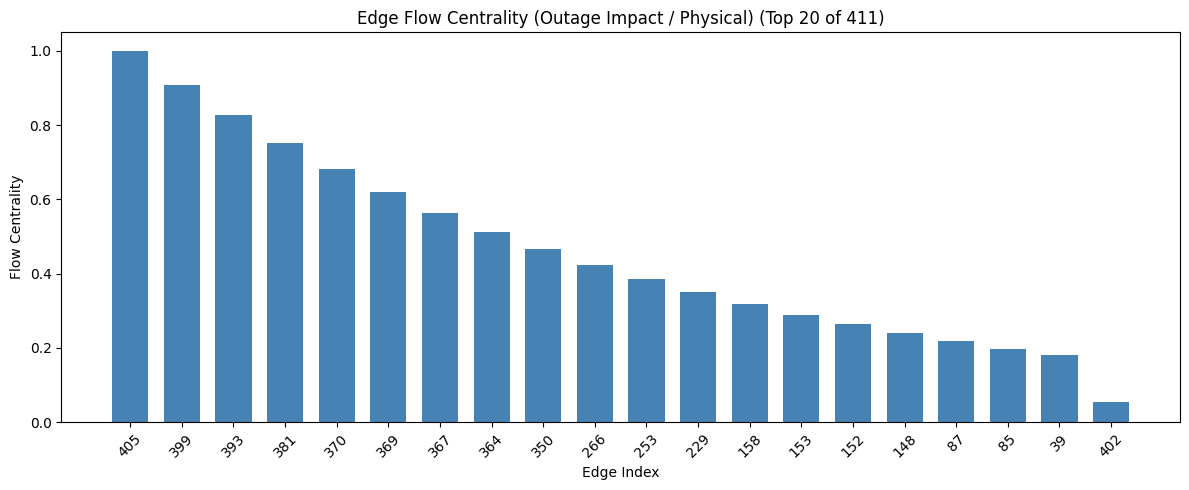

In [511]:
# compute edge betweeness centrality for our network and comapre to flow centrality of outages
edge_betweenness = compute_edge_betweeness(G)
print(f'Edge Betweenness Centrality:\n {edge_betweenness}')


# plot edge betweeness and flow for comparison between topological and physical centrtality measures
plot_top_k(edge_betweenness, title='Edge Betweenness Centrality (Topological)', xlabel='Edge Index', ylabel='Betweenness Centrality', color='steelblue')

plot_top_k(flow_centrality, title='Edge Flow Centrality (Outage Impact / Physical)', xlabel='Edge Index', ylabel='Flow Centrality', color='steelblue')


We compare the relationship between edge betweenness and flow centrality. On the IEEE-300 network the correlation between edge betweenness and physical flow is weak.

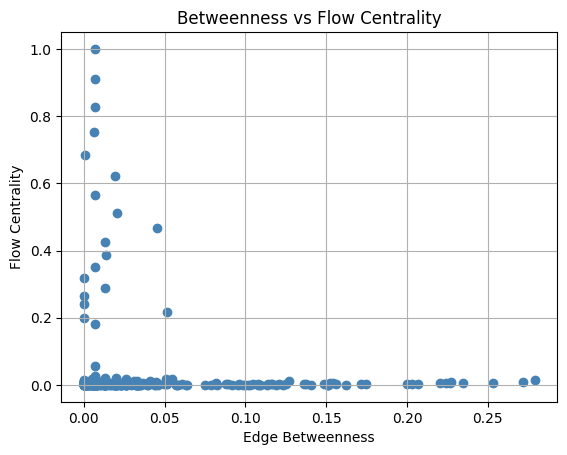

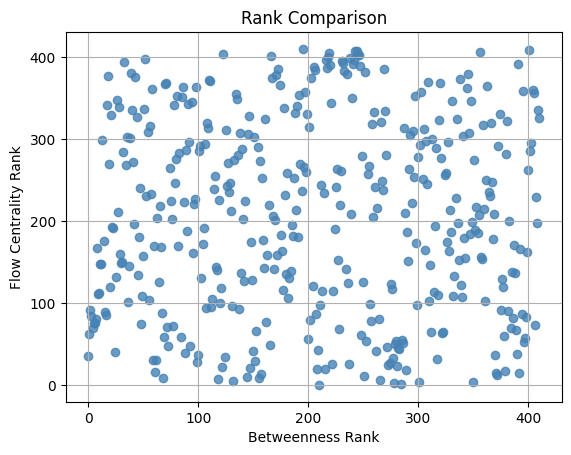

In [512]:
# print scatter plot comparing edge betweenness and flow centrality
plot_scatter(edge_betweenness, flow_centrality, xlabel='Edge Betweenness', ylabel='Flow Centrality', title='Betweenness vs Flow Centrality')

# print scatter plot comparing edge betweenness and flow centrality ranks
rank_flow = np.argsort(np.argsort(flow_centrality)[::-1])
rank_betw = np.argsort(np.argsort(edge_betweenness)[::-1])
plot_scatter(rank_betw, rank_flow, xlabel='Betweenness Rank', ylabel='Flow Centrality Rank', title='Rank Comparison', alpha=0.8)


Comparing AC vs DC power flow for link on IEEE-300 network. 

For the IEEE-300 network, the DC approximation still preserves the general ranking of critical lines, but the agreement in impact magnitudes is weaker. 

The reduced top-k overlap suggests that DC may miss some of the most critical lines in larger and more complex systems.

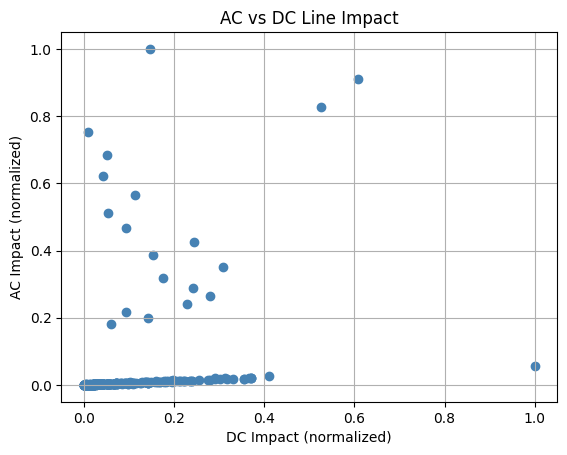

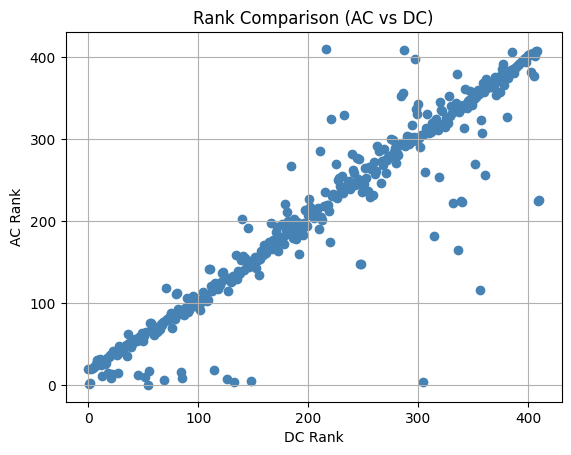

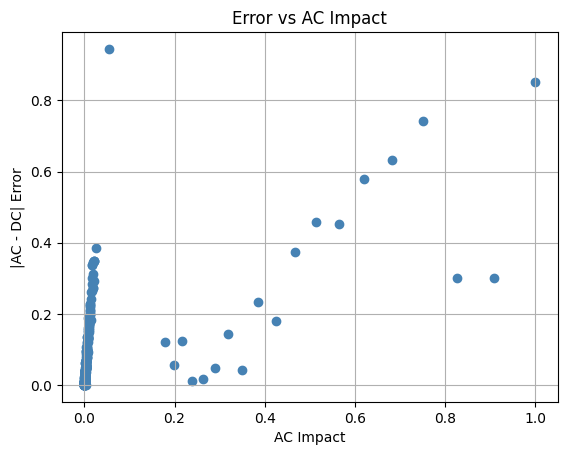

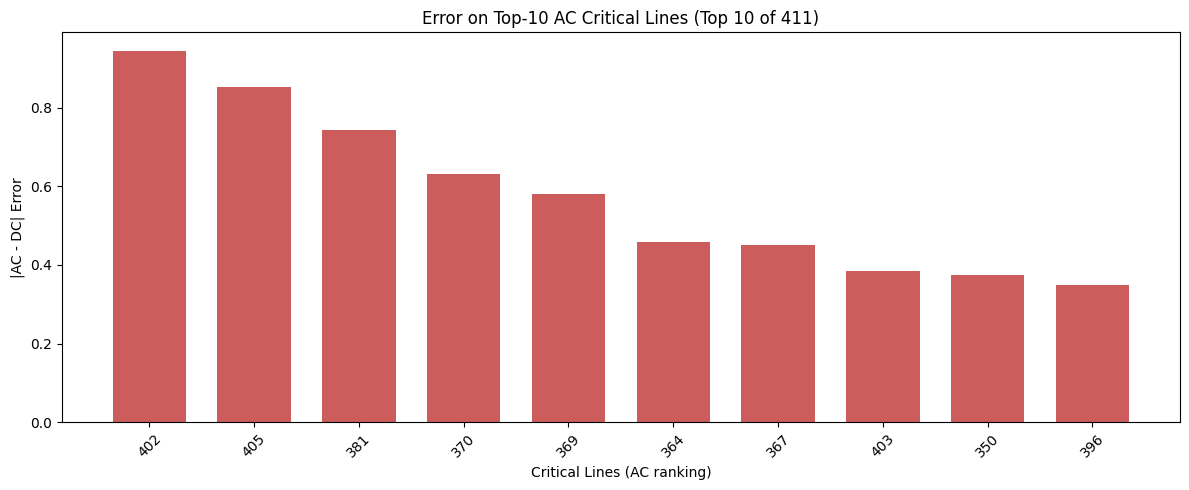


Top 10 Lines with Largest AC vs DC Difference:
Line 402: AC=0.055, DC=1.000, Error=0.945
Line 405: AC=1.000, DC=0.148, Error=0.852
Line 381: AC=0.751, DC=0.008, Error=0.743
Line 370: AC=0.683, DC=0.051, Error=0.632
Line 369: AC=0.621, DC=0.041, Error=0.579
Line 364: AC=0.513, DC=0.054, Error=0.459
Line 367: AC=0.564, DC=0.113, Error=0.452
Line 403: AC=0.025, DC=0.411, Error=0.385
Line 350: AC=0.467, DC=0.093, Error=0.374
Line 396: AC=0.021, DC=0.370, Error=0.349

IEEE-300 Global Metrics (AC vs DC):
Top-10 overlap:            0.20
Spearman Rank Correlation: 0.947
Pearson Correlation:       0.326
MAE:                       0.0643
RMSE:                      0.1299


In [513]:
# calculate flow centrality for both AC and DC power
flow_centrality_ac = compute_flow_centrality(network, G, edges, use_dc=False, normalize=True)
flow_centrality_dc = compute_flow_centrality(network, G, edges, use_dc=True, normalize=True)

# calculate error between AC and DC power flows
error = np.abs(flow_centrality_ac - flow_centrality_dc)

# calculate ranks for AC and DC power flows
rank_ac = flow_centrality_ac.argsort()[::-1].argsort()
rank_dc = flow_centrality_dc.argsort()[::-1].argsort()

# print scatter plots for comparing AC vs DC to analyze how well DC approximates AC for line impact and ranking
plot_scatter(flow_centrality_dc, flow_centrality_ac, xlabel='DC Impact (normalized)', ylabel='AC Impact (normalized)', title='AC vs DC Line Impact')

plot_scatter(rank_dc, rank_ac, xlabel='DC Rank', ylabel='AC Rank', title='Rank Comparison (AC vs DC)')

plot_scatter(flow_centrality_ac, error, xlabel='AC Impact', ylabel='|AC - DC| Error', title='Error vs AC Impact')

# compute top k overlap between AC and DC rankings to see if DC misses critical lines that AC identifies
top_k = 10
top_ac_idx = np.argsort(flow_centrality_ac)[::-1][:top_k]
top_dc_idx = np.argsort(flow_centrality_dc)[::-1][:top_k]

overlap_ac_dc = len(set(top_ac_idx) & set(top_dc_idx)) / top_k

plot_top_k(error, order_by=flow_centrality_ac, xlabel='Critical Lines (AC ranking)', ylabel='|AC - DC| Error', 
           title=f'Error on Top-{top_k} AC Critical Lines', top_k=top_k, color='indianred')

# print top k lines with the largest error between AC and DC
worst_idx = np.argsort(error)[::-1][:top_k]

print(f'\nTop {top_k} Lines with Largest AC vs DC Difference:')
for i in worst_idx:
    print(f'Line {i}: AC={flow_centrality_ac[i]:.3f}, DC={flow_centrality_dc[i]:.3f}, Error={error[i]:.3f}')

# print correlation and error metrics for given network to see how AC and DC compare overall
spearman_corr, _ = spearmanr(flow_centrality_ac, flow_centrality_dc)
pearson_corr, _ = pearsonr(flow_centrality_ac, flow_centrality_dc)
mae = np.mean(error)
rmse = np.sqrt(np.mean(error**2))

# store current network results for later comparison
network_results.append({
    'network': network_name,
    'overlap_ac_dc': overlap_ac_dc,
    'spearman_corr': spearman_corr,
    'pearson_corr': pearson_corr,
    'mae': mae,
    'rmse': rmse
})

# print summaary of results of current network
print(f'\n{network_name} Global Metrics (AC vs DC):')
print(f'Top-{top_k} overlap:            {overlap_ac_dc:.2f}')
print(f'Spearman Rank Correlation: {spearman_corr:.3f}')
print(f'Pearson Correlation:       {pearson_corr:.3f}')
print(f'MAE:                       {mae:.4f}')
print(f'RMSE:                      {rmse:.4f}')

Summary of AC vs DC Comparison Across Networks.

The results show that across our tested networks, DC power flow generally preserves the ranking of critical lines, but its accuracy in estimating impact magnitudes varies.

While DC performs very well for IEEE-14 and IEEE-118, it is less reliable for IEEE-57 and IEEE-300, particularly in identifying the most critical lines.

These findings suggest that, especially for larger or more complex power grids, directly approximating the AC power metric may be more reliable than relying solely on standard DC power flow when evaluating link centrality.

In [514]:
# print summary of results of all networks we tested so far for comparison
print('\nSummary of AC vs DC Power Flow Comparison Across Networks:\n')
results_df = pd.DataFrame(network_results)
results_df[['network', 'overlap_ac_dc', 'spearman_corr', 'pearson_corr', 'mae', 'rmse']]


Summary of AC vs DC Power Flow Comparison Across Networks:



,network,overlap_ac_dc,spearman_corr,pearson_corr,mae,rmse
0,IEEE-14,1.0,0.998496,0.998670,0.020733,0.023967
1,IEEE-57,0.5,0.916778,0.126462,0.160040,0.259492
2,IEEE-118,0.9,0.976328,0.994996,0.006610,0.013286
3,IEEE-300,0.2,0.947256,0.326446,0.064293,0.129909
